In [62]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.lines import Line2D
import pandas as pd


In [63]:
CLASSIF_METHODS = ["ClassifWrapSA(LogisticRegression)",
                   "ClassifWrapSA(SVC)",
                   "ClassifWrapSA(KNeighborsClassifier)",
                   "ClassifWrapSA(DecisionTreeClassifier)",
                   "ClassifWrapSA(RandomForestClassifier)",
                   "ClassifWrapSA(GradientBoostingClassifier)"]

REGR_METHODS = ["RegrWrapSA(ElasticNet)",
                "RegrWrapSA(DecisionTreeRegressor)",
                "RegrWrapSA(RandomForestRegressor)",
                "RegrWrapSA(GradientBoostingRegressor)",
                "RegrWrapSA(SVR)",
                "RegrWrapSA(KNeighborsRegressor)"]

SURV_METHODS = ["SAWrapSA(KaplanMeierFitter)",
                "CoxPHSurvivalAnalysis",
                "RandomSurvivalForest",
                "SurvivalTree",
                "GradientBoostingSurvivalAnalysis",
                "CRAID",
                "ParallelBootstrapCRAID"]

In [64]:
df = pd.read_excel('UI/tables/pbc.xlsx')

In [65]:
df_metrics = df[["METHOD", 'CI_mean', 'IBS_mean', 'AUPRC_mean', 
                 'RMSE_TIME_mean', 'R2_TIME_mean', 
                 'AUC_EVENT_mean', 'LOGLOSS_EVENT_mean', 'RMSE_EVENT_mean'
                ]]

In [66]:
bad_example = ["BAD", 0.5, 0.25, 0.5, 100000.0, -10.0, 0.5, 1.0, 100000.0]
good_example = ["GOOD", 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0]

df_metrics = pd.concat([df_metrics, pd.DataFrame([bad_example, good_example],
                                                 columns=df_metrics.columns)], ignore_index=True)
df_metrics.iloc[:, 1:] = df_metrics.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

In [67]:
df_metrics = df_metrics[["METHOD", 'CI_mean', 'IBS_mean', 'AUPRC_mean', 
                 'RMSE_TIME_mean', 'R2_TIME_mean', 
                #  'AUC_EVENT_mean', 'LOGLOSS_EVENT_mean', 'RMSE_EVENT_mean'
                ]]

### TSNE Visualization

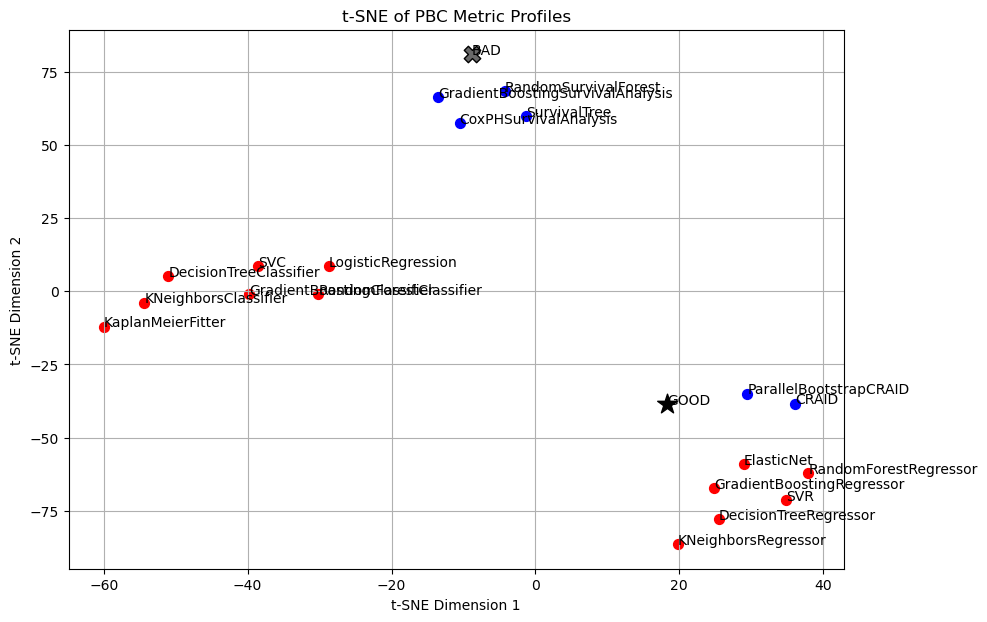

In [68]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# t-SNE here shows similarity of metric profiles on PBC, not the global leaderboard rank.
tsne_df = df_metrics.copy()
real_mask = ~tsne_df['METHOD'].isin(['GOOD', 'BAD'])
tsne_features = tsne_df.drop(columns=['METHOD']).apply(pd.to_numeric, errors='coerce').copy()
for col in ['IBS_mean', 'RMSE_TIME_mean']:
    tsne_features[col] = -tsne_features[col]

scaler = StandardScaler().fit(tsne_features.loc[real_mask])
scaled_metrics = scaler.transform(tsne_features)
perplexity = max(2, min(5, len(tsne_df) - 1))
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, init='pca', learning_rate='auto')
tsne_results = tsne.fit_transform(scaled_metrics)
plt.figure(figsize=(10, 7))
# plt.scatter(tsne_results[:, 0], tsne_results[:, 1])
for i, method in enumerate(tsne_df['METHOD']):
    marker = 'o'
    size = 50
    edgecolor = None
    if method == 'GOOD':
        color = 'black'
        marker = '*'
        size = 220
        edgecolor = 'black'
    elif method == 'BAD':
        color = 'dimgray'
        marker = 'X'
        size = 140
        edgecolor = 'black'
    elif method in SURV_METHODS:
        color = 'blue'
    elif method in CLASSIF_METHODS:
        color = 'green'
    elif method in REGR_METHODS:
        color = 'orange'
    else:
        color = 'red'
    plt.scatter(tsne_results[i, 0], tsne_results[i, 1], color=color, marker=marker, s=size, edgecolors=edgecolor)
    plt.annotate(method, (tsne_results[i, 0], tsne_results[i, 1]))
plt.title('t-SNE of PBC Metric Profiles')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid()
plt.show()

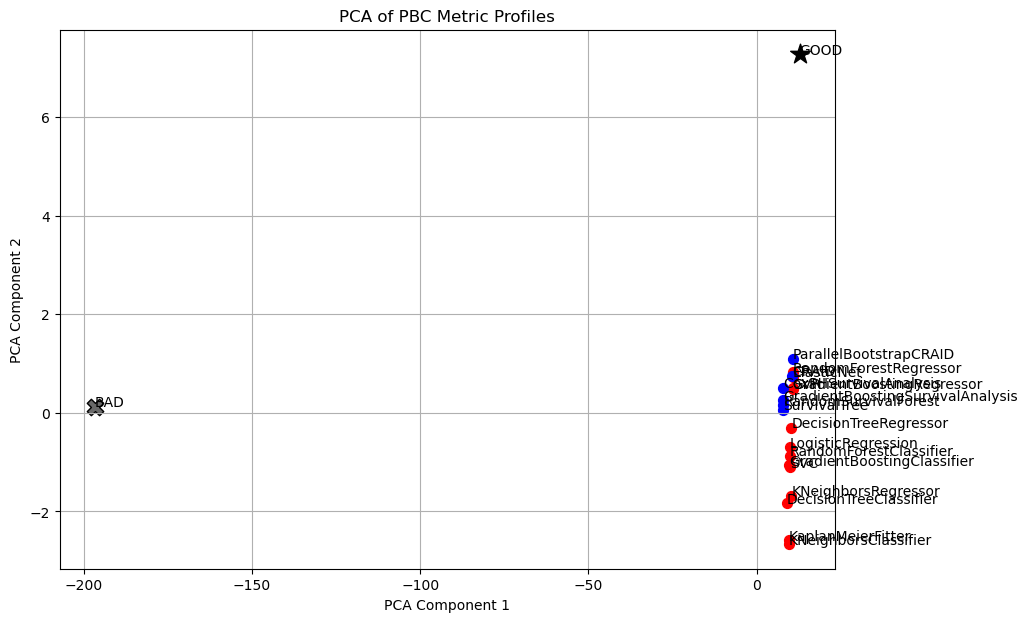

In [69]:
### PCA Visualization

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_df = df_metrics.copy()
real_mask = ~pca_df['METHOD'].isin(['GOOD', 'BAD'])
pca_features = pca_df.drop(columns=['METHOD']).apply(pd.to_numeric, errors='coerce').copy()
for col in ['IBS_mean', 'RMSE_TIME_mean']:
    pca_features[col] = -pca_features[col]

scaler = StandardScaler().fit(pca_features.loc[real_mask])
scaled_metrics = scaler.transform(pca_features)

pca = PCA(n_components=2)
pca_results = pca.fit_transform(scaled_metrics)
plt.figure(figsize=(10, 7))

for i, method in enumerate(pca_df['METHOD']):
    marker = 'o'
    size = 50
    edgecolor = None
    if method == 'GOOD':
        color = 'black'
        marker = '*'
        size = 220
        edgecolor = 'black'
    elif method == 'BAD':
        color = 'dimgray'
        marker = 'X'
        size = 140
        edgecolor = 'black'
    elif method in SURV_METHODS:
        color = 'blue'
    elif method in CLASSIF_METHODS:
        color = 'green'
    elif method in REGR_METHODS:
        color = 'orange'
    else:
        color = 'red'
    plt.scatter(pca_results[i, 0], pca_results[i, 1], color=color, marker=marker, s=size, edgecolors=edgecolor)
    plt.annotate(method, (pca_results[i, 0], pca_results[i, 1]))

plt.title('PCA of PBC Metric Profiles')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid()
plt.show()

d:\Users\DimonZhi\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


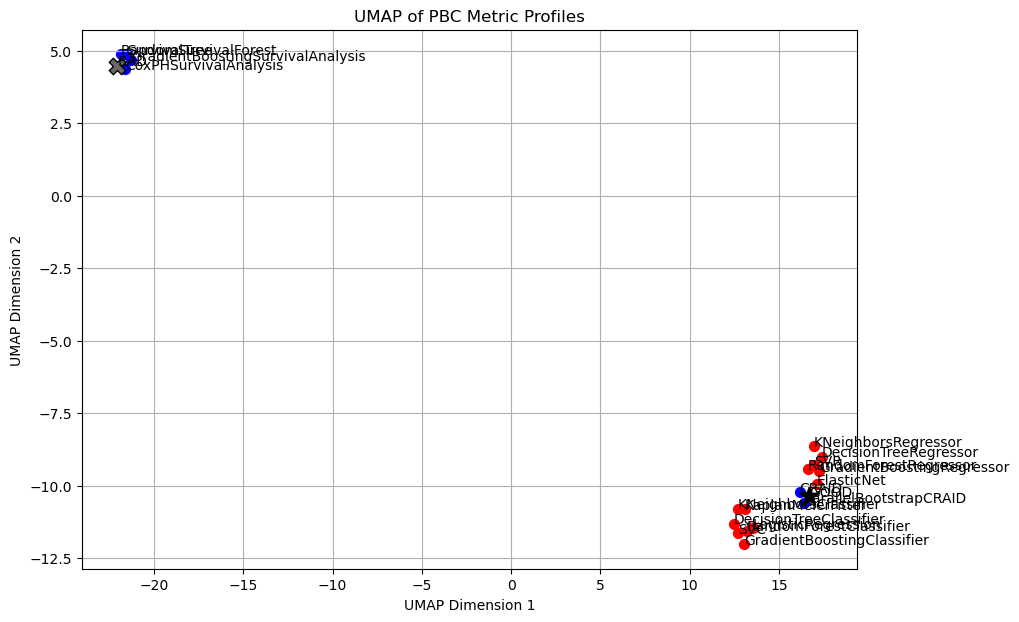

In [70]:
### UMAP Visualization

from umap import UMAP
from sklearn.preprocessing import StandardScaler

umap_df = df_metrics.copy()
real_mask = ~umap_df['METHOD'].isin(['GOOD', 'BAD'])
umap_features = umap_df.drop(columns=['METHOD']).apply(pd.to_numeric, errors='coerce').copy()
for col in ['IBS_mean', 'RMSE_TIME_mean']:
    umap_features[col] = -umap_features[col]

scaler = StandardScaler().fit(umap_features.loc[real_mask])
scaled_metrics = scaler.transform(umap_features)
n_neighbors = max(2, min(8, len(umap_df) - 1))

umap = UMAP(n_components=2, n_neighbors=n_neighbors, random_state=42, min_dist=0.1)
umap_results = umap.fit_transform(scaled_metrics)
plt.figure(figsize=(10, 7))

for i, method in enumerate(umap_df['METHOD']):
    marker = 'o'
    size = 50
    edgecolor = None
    if method == 'GOOD':
        color = 'black'
        marker = '*'
        size = 220
        edgecolor = 'black'
    elif method == 'BAD':
        color = 'dimgray'
        marker = 'X'
        size = 140
        edgecolor = 'black'
    elif method in SURV_METHODS:
        color = 'blue'
    elif method in CLASSIF_METHODS:
        color = 'green'
    elif method in REGR_METHODS:
        color = 'orange'
    else:
        color = 'red'
    plt.scatter(umap_results[i, 0], umap_results[i, 1], color=color, marker=marker, s=size, edgecolors=edgecolor)
    plt.annotate(method, (umap_results[i, 0], umap_results[i, 1]))

plt.title('UMAP of PBC Metric Profiles')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.grid()
plt.show()

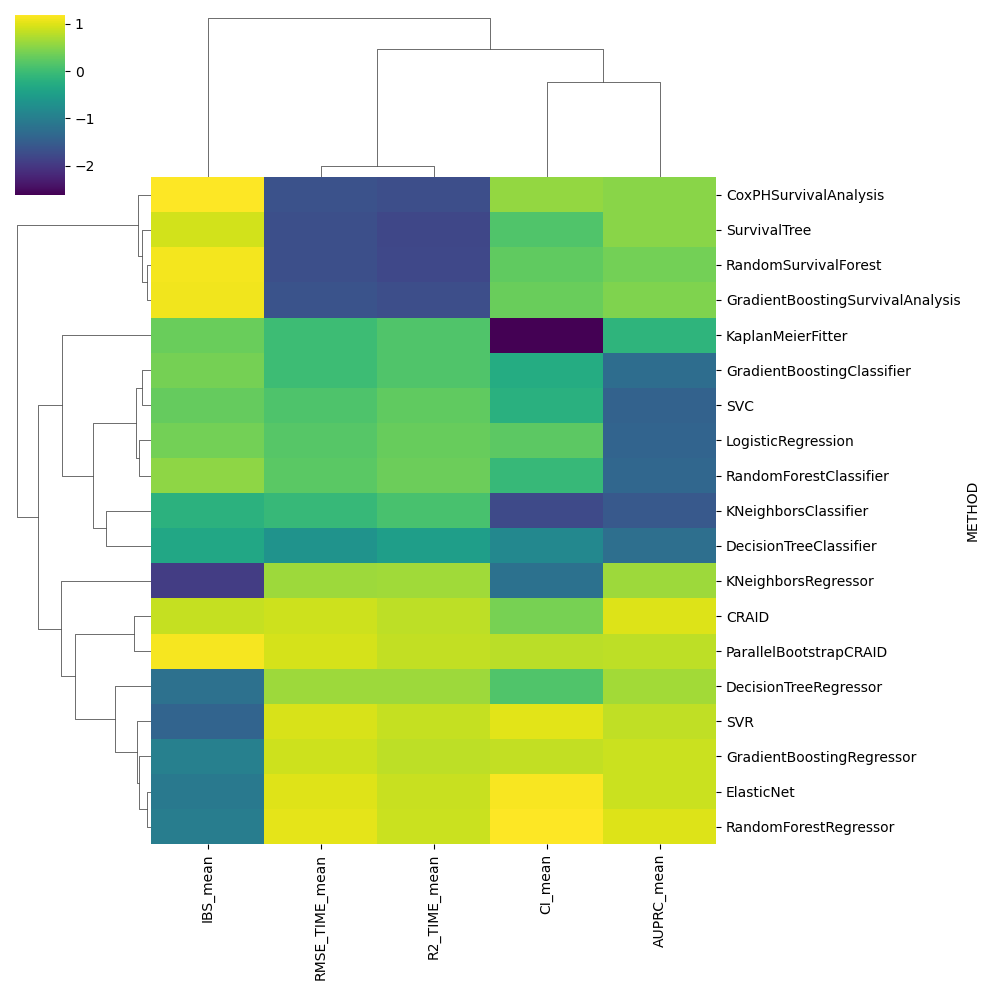

In [71]:
import seaborn as sns

cluster_df = df_metrics[~df_metrics['METHOD'].isin(['GOOD', 'BAD'])].copy()
cluster_features = cluster_df.drop(columns=['METHOD']).apply(pd.to_numeric, errors='coerce').copy()
for col in ['IBS_mean', 'RMSE_TIME_mean']:
    cluster_features[col] = -cluster_features[col]
cluster_features.index = cluster_df['METHOD']

sns.clustermap(cluster_features.astype(float),
               cmap='viridis',
               z_score=1,
               col_cluster=True,
               row_cluster=True)

,Method,CLASSIFICATION_Avg_Position,SURVIVAL_Avg_Position,group,family_name,family_label,base_model,base_model_short,times,plot_label,delta,abs_delta
0,RandomForestClassifier,2.000000,13.571429,classification,,Classification,RandomForestClassifier,RF,None,RandomForestClassifier,-11.571429,11.571429
1,GradientBoostingClassifier,2.142857,13.428571,classification,,Classification,GradientBoostingClassifier,GB,None,GradientBoostingClassifier,-11.285714,11.285714
2,LogisticRegression,4.714286,13.571429,classification,,Classification,LogisticRegression,LR,None,LogisticRegression,-8.857143,8.857143
3,GradientBoostingSurvivalAnalysis,4.857143,3.285714,survival,,Survival,GradientBoostingSurvivalAnalysis,GBSA,None,GradientBoostingSurvivalAnalysis,1.571429,1.571429
4,SVC,5.571429,14.714286,classification,,Classification,SVC,SVC,None,SVC,-9.142857,9.142857
5,RandomSurvivalForest,6.428571,5.714286,survival,,Survival,RandomSurvivalForest,RSF,None,RandomSurvivalForest,0.714286,0.714286
6,ParallelBootstrapCRAID,7.285714,1.285714,survival,,Survival,ParallelBootstrapCRAID,PB-CRAID,None,ParallelBootstrapCRAID,6.000000,6.000000
7,CoxPHSurvivalAnalysis,8.428571,6.428571,survival,,Survival,CoxPHSurvivalAnalysis,CoxPH,None,CoxPHSurvivalAnalysis,2.000000,2.000000
8,CRAID,9.714286,3.000000,survival,,Survival,CRAID,CRAID,None,CRAID,6.714286,6.714286
9,ElasticNet,12.000000,8.142857,regression,,Regression,ElasticNet,ElasticNet,None,ElasticNet,3.857143,3.857143


,Method,plot_label,family_label,base_model,times,CLASSIFICATION_Avg_Position,SURVIVAL_Avg_Position,delta,abs_delta
0,RandomForestClassifier,RandomForestClassifier,Classification,RandomForestClassifier,None,2.000000,13.571429,-11.571429,11.571429
1,GradientBoostingClassifier,GradientBoostingClassifier,Classification,GradientBoostingClassifier,None,2.142857,13.428571,-11.285714,11.285714
2,LogisticRegression,LogisticRegression,Classification,LogisticRegression,None,4.714286,13.571429,-8.857143,8.857143
3,GradientBoostingSurvivalAnalysis,GradientBoostingSurvivalAnalysis,Survival,GradientBoostingSurvivalAnalysis,None,4.857143,3.285714,1.571429,1.571429
4,SVC,SVC,Classification,SVC,None,5.571429,14.714286,-9.142857,9.142857
5,RandomSurvivalForest,RandomSurvivalForest,Survival,RandomSurvivalForest,None,6.428571,5.714286,0.714286,0.714286
6,ParallelBootstrapCRAID,ParallelBootstrapCRAID,Survival,ParallelBootstrapCRAID,None,7.285714,1.285714,6.000000,6.000000
7,CoxPHSurvivalAnalysis,CoxPHSurvivalAnalysis,Survival,CoxPHSurvivalAnalysis,None,8.428571,6.428571,2.000000,2.000000
8,CRAID,CRAID,Survival,CRAID,None,9.714286,3.000000,6.714286,6.714286
9,ElasticNet,ElasticNet,Regression,ElasticNet,None,12.000000,8.142857,3.857143,3.857143


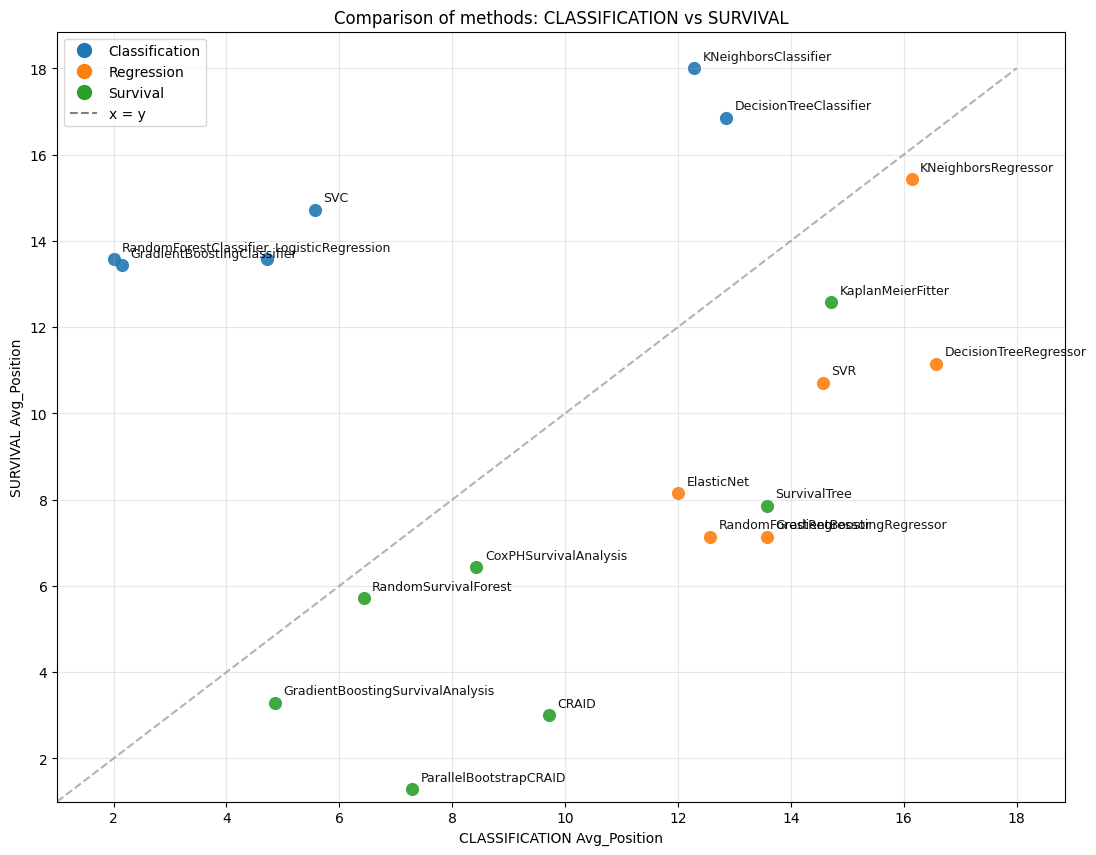

In [9]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

LEADERBOARD_PATH = "UI/tables/leaderboards_by_task.xlsx"
USE_COL = "Avg_Position"

SHEET_MAP = {
    "CLASSIFICATION": "OVERALL_CLASSIFICATION",
    "REGRESSION": "OVERALL_REGRESSION",
    "SURVIVAL": "OVERALL_SURVIVAL",
    "ALL": "OVERALL_ALL",
}

CLASSIF_MODELS = [
    "LogisticRegression",
    "KNeighborsClassifier",
    "DecisionTreeClassifier",
    "RandomForestClassifier",
    "GradientBoostingClassifier",
    "SVC",
]

REGR_MODELS = [
    "ElasticNet",
    "DecisionTreeRegressor",
    "RandomForestRegressor",
    "GradientBoostingRegressor",
    "SVR",
    "KNeighborsRegressor",
]

SURV_MODELS = [
    "KaplanMeierFitter",
    "CoxPHSurvivalAnalysis",
    "RandomSurvivalForest",
    "SurvivalTree",
    "GradientBoostingSurvivalAnalysis",
    "CRAID",
    "ParallelBootstrapCRAID",
]

SHORT_MODEL_NAMES = {
    "LogisticRegression": "LR",
    "KNeighborsClassifier": "KNN",
    "DecisionTreeClassifier": "DT",
    "RandomForestClassifier": "RF",
    "GradientBoostingClassifier": "GB",
    "DecisionTreeRegressor": "DT-R",
    "RandomForestRegressor": "RF-R",
    "GradientBoostingRegressor": "GB-R",
    "KNeighborsRegressor": "KNN-R",
    "KaplanMeierFitter": "KMF",
    "CoxPHSurvivalAnalysis": "CoxPH",
    "RandomSurvivalForest": "RSF",
    "SurvivalTree": "ST",
    "GradientBoostingSurvivalAnalysis": "GBSA",
    "ParallelBootstrapCRAID": "PB-CRAID",
}

PIECEWISE_PATTERN = re.compile(
    r"^(Piecewise(?:CensorAware)?ClassifWrapSA)\(([^,]+),\s*times=(\d+)\)$"
)

PIECEWISE_GROUPS = {
    "PiecewiseClassifWrapSA": "piecewise",
    "PiecewiseCensorAwareClassifWrapSA": "piecewise_censor_aware",
}

METHOD_STYLES = {
    "classification": {"label": "Classification", "color": "tab:blue"},
    "regression": {"label": "Regression", "color": "tab:orange"},
    "survival": {"label": "Survival", "color": "tab:green"},
    "piecewise": {"label": "PiecewiseClassifWrapSA", "color": "#ef4444"},
    "piecewise_censor_aware": {"label": "PiecewiseCensorAwareClassifWrapSA", "color": "#facc15"},
    "other": {"label": "Other", "color": "tab:gray"},
}

TIME_MARKERS = {
    4: "D",
    8: "P",
    16: "X",
    32: "*",
}

TIME_SIZES = {
    4: 125,
    8: 145,
    16: 165,
    32: 220,
}

TIME_LABELS = {
    4: "times=4",
    8: "times=8",
    16: "times=16",
    32: "times=32",
}

SELECTED_PIECEWISE_TIMES = {16}

def parse_piecewise_method(method):
    match = PIECEWISE_PATTERN.match(str(method))
    if not match:
        return None

    family_name, base_model, times = match.groups()
    group = PIECEWISE_GROUPS[family_name]
    times = int(times)
    short_model = SHORT_MODEL_NAMES.get(base_model, base_model)

    return {
        "group": group,
        "family_name": family_name,
        "family_label": METHOD_STYLES[group]["label"],
        "base_model": base_model,
        "base_model_short": base_model,
        "times": times,
        "plot_label": f"{base_model} t={times}",
    }



def method_metadata(method):
    piecewise = parse_piecewise_method(method)
    if piecewise is not None:
        return piecewise

    if method in CLASSIF_MODELS:
        group = "classification"
    elif method in REGR_MODELS:
        group = "regression"
    elif method in SURV_MODELS:
        group = "survival"
    else:
        group = "other"

    return {
        "group": group,
        "family_name": "",
        "family_label": METHOD_STYLES[group]["label"],
        "base_model": method,
        "base_model_short": SHORT_MODEL_NAMES.get(method, method),
        "times": None,
        "plot_label": method,
    }



def style_for_method(method):
    meta = method_metadata(method)
    style = METHOD_STYLES[meta["group"]].copy()

    if meta["times"] is None:
        style.update({
            "marker": "o",
            "size": 90,
            "edgecolor": style["color"],
            "linewidth": 0,
        })
    else:
        style.update({
            "marker": TIME_MARKERS.get(meta["times"], "^"),
            "size": TIME_SIZES.get(meta["times"], 150),
            "edgecolor": "black",
            "linewidth": 0.85,
        })

    return style



def build_legend_elements(cmp):
    legend = []
    present_groups = list(dict.fromkeys(cmp["group"].tolist()))

    for group_name in ["classification", "regression", "survival", "piecewise", "piecewise_censor_aware", "other"]:
        if group_name not in present_groups:
            continue
        style = METHOD_STYLES[group_name]
        legend.append(
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                label=style["label"],
                markerfacecolor=style["color"],
                markeredgecolor=style["color"],
                markersize=10,
            )
        )

    present_times = sorted({int(value) for value in cmp["times"].dropna().tolist()})
    for times in present_times:
        legend.append(
            Line2D(
                [0],
                [0],
                marker=TIME_MARKERS.get(times, "^"),
                color="black",
                label=TIME_LABELS.get(times, f"times={times}"),
                markerfacecolor="white",
                markeredgecolor="black",
                linestyle="None",
                markersize=10,
            )
        )

    legend.append(Line2D([0], [0], linestyle="--", color="gray", label="x = y"))
    return legend



def render_task_comparison(task_x, task_y, use_col=USE_COL):
    x_col = f"{task_x}_{use_col}"
    y_col = f"{task_y}_{use_col}"

    df_x = pd.read_excel(LEADERBOARD_PATH, sheet_name=SHEET_MAP[task_x])
    df_y = pd.read_excel(LEADERBOARD_PATH, sheet_name=SHEET_MAP[task_y])

    df_x = df_x[["Method", use_col]].rename(columns={use_col: x_col})
    df_y = df_y[["Method", use_col]].rename(columns={use_col: y_col})

    cmp = df_x.merge(df_y, on="Method", how="inner")
    meta = cmp["Method"].apply(method_metadata).apply(pd.Series)
    cmp = pd.concat([cmp, meta], axis=1)
    cmp = cmp[cmp["times"].isna() | cmp["times"].isin(SELECTED_PIECEWISE_TIMES)].copy()
    cmp["delta"] = cmp[x_col] - cmp[y_col]
    cmp["abs_delta"] = cmp["delta"].abs()
    cmp = cmp.sort_values([x_col, y_col, "group", "times", "Method"], na_position="last").reset_index(drop=True)

    display(cmp)

    rank_table = cmp[[
        "Method",
        "plot_label",
        "family_label",
        "base_model",
        "times",
        x_col,
        y_col,
        "delta",
        "abs_delta",
    ]].copy()
    display(rank_table)

    plt.figure(figsize=(13, 10))

    for _, row in cmp.iterrows():
        style = style_for_method(row["Method"])
        plt.scatter(
            row[x_col],
            row[y_col],
            color=style["color"],
            marker=style["marker"],
            s=style["size"],
            alpha=0.9,
            edgecolors=style["edgecolor"],
            linewidths=style["linewidth"],
        )
        plt.annotate(
            row["plot_label"],
            (row[x_col], row[y_col]),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=9,
            alpha=0.92,
        )

    xy_min = 1
    xy_max = max(cmp[x_col].max(), cmp[y_col].max())
    plt.plot([xy_min, xy_max], [xy_min, xy_max], "--", color="gray", alpha=0.6)
    plt.xlim(left=xy_min)
    plt.ylim(bottom=xy_min)
    plt.legend(handles=build_legend_elements(cmp), loc="best")

    plt.xlabel(f"{task_x} {use_col}")
    plt.ylabel(f"{task_y} {use_col}")
    plt.title(f"Comparison of methods: {task_x} vs {task_y}")
    plt.grid(alpha=0.3)
    plt.show()

    return cmp, rank_table


cmp_cs, rank_cs = render_task_comparison("CLASSIFICATION", "SURVIVAL")


,Method,SURVIVAL_Avg_Position,REGRESSION_Avg_Position,group,family_name,family_label,base_model,base_model_short,times,plot_label,delta,abs_delta
0,ParallelBootstrapCRAID,1.285714,4.000000,survival,,Survival,ParallelBootstrapCRAID,PB-CRAID,None,ParallelBootstrapCRAID,-2.714286,2.714286
1,CRAID,3.000000,6.142857,survival,,Survival,CRAID,CRAID,None,CRAID,-3.142857,3.142857
2,GradientBoostingSurvivalAnalysis,3.285714,12.428571,survival,,Survival,GradientBoostingSurvivalAnalysis,GBSA,None,GradientBoostingSurvivalAnalysis,-9.142857,9.142857
3,RandomSurvivalForest,5.714286,16.714286,survival,,Survival,RandomSurvivalForest,RSF,None,RandomSurvivalForest,-11.000000,11.000000
4,CoxPHSurvivalAnalysis,6.428571,13.000000,survival,,Survival,CoxPHSurvivalAnalysis,CoxPH,None,CoxPHSurvivalAnalysis,-6.571429,6.571429
5,RandomForestRegressor,7.142857,1.714286,regression,,Regression,RandomForestRegressor,RF-R,None,RandomForestRegressor,5.428571,5.428571
6,GradientBoostingRegressor,7.142857,2.714286,regression,,Regression,GradientBoostingRegressor,GB-R,None,GradientBoostingRegressor,4.428571,4.428571
7,SurvivalTree,7.857143,17.857143,survival,,Survival,SurvivalTree,ST,None,SurvivalTree,-10.000000,10.000000
8,ElasticNet,8.142857,3.714286,regression,,Regression,ElasticNet,ElasticNet,None,ElasticNet,4.428571,4.428571
9,SVR,10.714286,6.000000,regression,,Regression,SVR,SVR,None,SVR,4.714286,4.714286


,Method,plot_label,family_label,base_model,times,SURVIVAL_Avg_Position,REGRESSION_Avg_Position,delta,abs_delta
0,ParallelBootstrapCRAID,ParallelBootstrapCRAID,Survival,ParallelBootstrapCRAID,None,1.285714,4.000000,-2.714286,2.714286
1,CRAID,CRAID,Survival,CRAID,None,3.000000,6.142857,-3.142857,3.142857
2,GradientBoostingSurvivalAnalysis,GradientBoostingSurvivalAnalysis,Survival,GradientBoostingSurvivalAnalysis,None,3.285714,12.428571,-9.142857,9.142857
3,RandomSurvivalForest,RandomSurvivalForest,Survival,RandomSurvivalForest,None,5.714286,16.714286,-11.000000,11.000000
4,CoxPHSurvivalAnalysis,CoxPHSurvivalAnalysis,Survival,CoxPHSurvivalAnalysis,None,6.428571,13.000000,-6.571429,6.571429
5,RandomForestRegressor,RandomForestRegressor,Regression,RandomForestRegressor,None,7.142857,1.714286,5.428571,5.428571
6,GradientBoostingRegressor,GradientBoostingRegressor,Regression,GradientBoostingRegressor,None,7.142857,2.714286,4.428571,4.428571
7,SurvivalTree,SurvivalTree,Survival,SurvivalTree,None,7.857143,17.857143,-10.000000,10.000000
8,ElasticNet,ElasticNet,Regression,ElasticNet,None,8.142857,3.714286,4.428571,4.428571
9,SVR,SVR,Regression,SVR,None,10.714286,6.000000,4.714286,4.714286


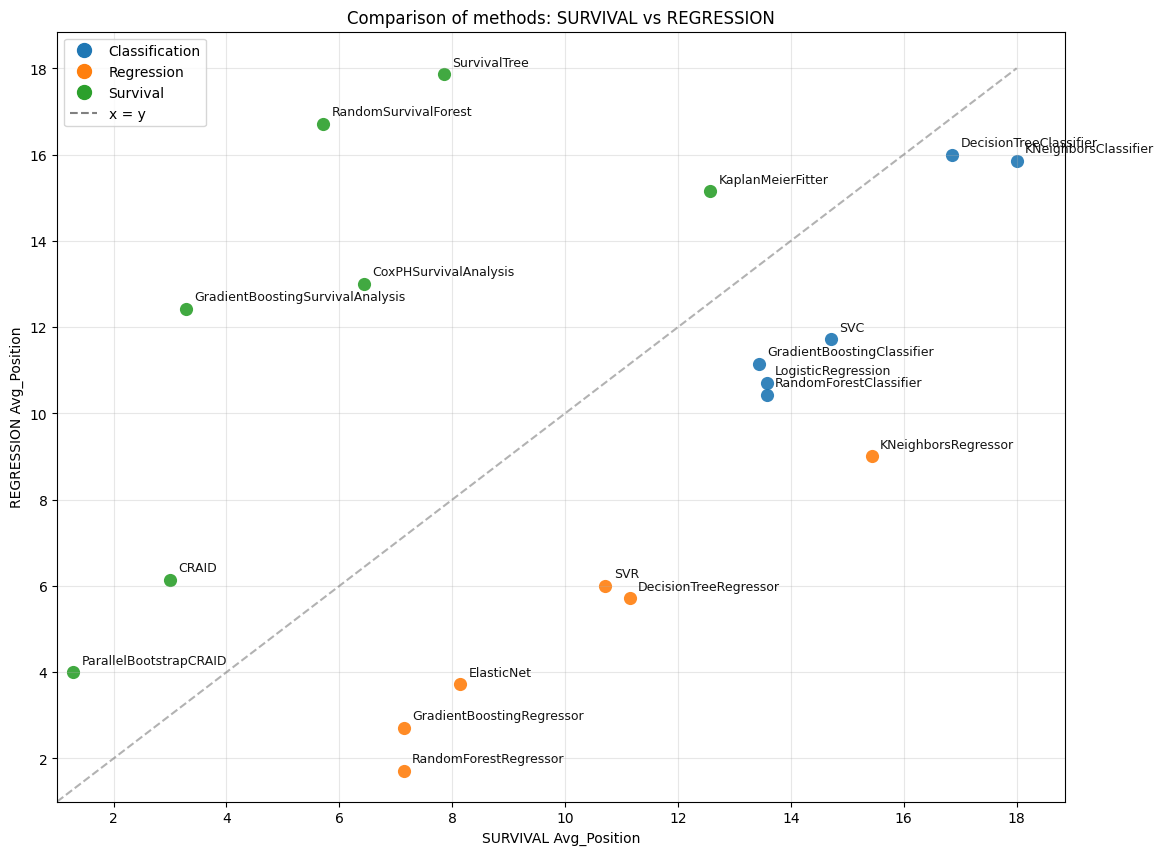

In [10]:
cmp_sr, rank_sr = render_task_comparison("SURVIVAL", "REGRESSION")


,Method,REGRESSION_Avg_Position,CLASSIFICATION_Avg_Position,group,family_name,family_label,base_model,base_model_short,times,plot_label,delta,abs_delta
0,RandomForestRegressor,1.714286,12.571429,regression,,Regression,RandomForestRegressor,RF-R,None,RandomForestRegressor,-10.857143,10.857143
1,GradientBoostingRegressor,2.714286,13.571429,regression,,Regression,GradientBoostingRegressor,GB-R,None,GradientBoostingRegressor,-10.857143,10.857143
2,ElasticNet,3.714286,12.000000,regression,,Regression,ElasticNet,ElasticNet,None,ElasticNet,-8.285714,8.285714
3,ParallelBootstrapCRAID,4.000000,7.285714,survival,,Survival,ParallelBootstrapCRAID,PB-CRAID,None,ParallelBootstrapCRAID,-3.285714,3.285714
4,DecisionTreeRegressor,5.714286,16.571429,regression,,Regression,DecisionTreeRegressor,DT-R,None,DecisionTreeRegressor,-10.857143,10.857143
5,SVR,6.000000,14.571429,regression,,Regression,SVR,SVR,None,SVR,-8.571429,8.571429
6,CRAID,6.142857,9.714286,survival,,Survival,CRAID,CRAID,None,CRAID,-3.571429,3.571429
7,KNeighborsRegressor,9.000000,16.142857,regression,,Regression,KNeighborsRegressor,KNN-R,None,KNeighborsRegressor,-7.142857,7.142857
8,RandomForestClassifier,10.428571,2.000000,classification,,Classification,RandomForestClassifier,RF,None,RandomForestClassifier,8.428571,8.428571
9,LogisticRegression,10.714286,4.714286,classification,,Classification,LogisticRegression,LR,None,LogisticRegression,6.000000,6.000000


,Method,plot_label,family_label,base_model,times,REGRESSION_Avg_Position,CLASSIFICATION_Avg_Position,delta,abs_delta
0,RandomForestRegressor,RandomForestRegressor,Regression,RandomForestRegressor,None,1.714286,12.571429,-10.857143,10.857143
1,GradientBoostingRegressor,GradientBoostingRegressor,Regression,GradientBoostingRegressor,None,2.714286,13.571429,-10.857143,10.857143
2,ElasticNet,ElasticNet,Regression,ElasticNet,None,3.714286,12.000000,-8.285714,8.285714
3,ParallelBootstrapCRAID,ParallelBootstrapCRAID,Survival,ParallelBootstrapCRAID,None,4.000000,7.285714,-3.285714,3.285714
4,DecisionTreeRegressor,DecisionTreeRegressor,Regression,DecisionTreeRegressor,None,5.714286,16.571429,-10.857143,10.857143
5,SVR,SVR,Regression,SVR,None,6.000000,14.571429,-8.571429,8.571429
6,CRAID,CRAID,Survival,CRAID,None,6.142857,9.714286,-3.571429,3.571429
7,KNeighborsRegressor,KNeighborsRegressor,Regression,KNeighborsRegressor,None,9.000000,16.142857,-7.142857,7.142857
8,RandomForestClassifier,RandomForestClassifier,Classification,RandomForestClassifier,None,10.428571,2.000000,8.428571,8.428571
9,LogisticRegression,LogisticRegression,Classification,LogisticRegression,None,10.714286,4.714286,6.000000,6.000000


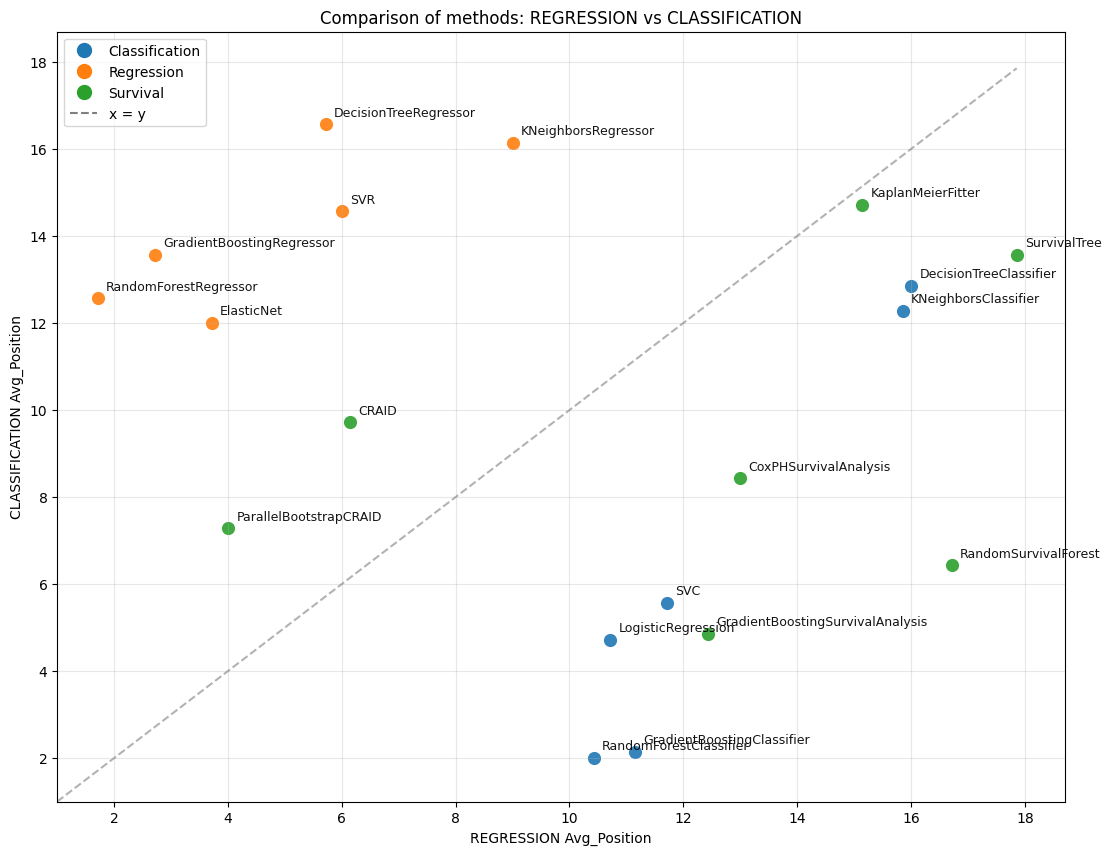

In [11]:
cmp_rc, rank_rc = render_task_comparison("REGRESSION", "CLASSIFICATION")


In [ ]:
# Presentation chart: best model inside each family.
# Bars show the rank (Avg_Position) of the best model in each approach, not the group average.

from pathlib import Path
import re

import pandas as pd
import matplotlib
if "get_ipython" not in globals():
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

RESULTS_CHART_DIR = Path("outputs/manual-sawrap-product/presentations/group-results-chart")
RESULTS_CHART_DIR.mkdir(parents=True, exist_ok=True)

leaderboard = pd.read_excel(LEADERBOARD_PATH, sheet_name="OVERALL_ALL")

PIECEWISE_PATTERN = re.compile(
    r"^(Piecewise(?:CensorAware)?ClassifWrapSA)\(([^,]+),\s*times=(\d+)\)$"
)

GROUP_LABELS = {
    "censor_aware_piecewise": "Censor-aware\npiecewise",
    "survival": "Survival\nanalysis",
    "regression": "Regression",
    "piecewise": "Piecewise",
    "classification": "Classification",
}

GROUP_COLORS = {
    "censor_aware_piecewise": "#1700FF",
    "survival": "#14A06F",
    "regression": "#FFB000",
    "piecewise": "#E85D5D",
    "classification": "#6C7280",
}

GROUP_ORDER = [
    "survival",
    "censor_aware_piecewise",
    "piecewise",
    "regression",
    "classification",
]

SHORT_MODEL_NAMES = {
    "ParallelBootstrapCRAID": "ParallelBootstrapCRAID",
    "CRAID": "CRAID",
    "GradientBoostingSurvivalAnalysis": "GB Survival",
    "RandomForestRegressor": "RandomForestRegressor",
    "GradientBoostingRegressor": "GBRegressor",
    "RandomForestClassifier": "RandomForestClassifier",
    "LogisticRegression": "LogisticRegression",
    "GradientBoostingClassifier": "GBClassifier",
}

SHORT_BASE_NAMES = {
    "LogisticRegression": "LogisticRegression",
    "RandomForestClassifier": "RFClassifier",
    "GradientBoostingClassifier": "GBClassifier",
    "DecisionTreeClassifier": "DTClassifier",
    "KNeighborsClassifier": "KNNClassifier",
}


def method_group(method):
    method = str(method)
    piecewise = PIECEWISE_PATTERN.match(method)
    if piecewise:
        family = piecewise.group(1)
        if family == "PiecewiseCensorAwareClassifWrapSA":
            return "censor_aware_piecewise"
        return "piecewise"
    if method.startswith("PWCens("):
        return "censor_aware_piecewise"
    if method.startswith("PW("):
        return "piecewise"
    if method in CLASSIF_MODELS:
        return "classification"
    if method in REGR_MODELS:
        return "regression"
    if method in SURV_MODELS:
        return "survival"
    return "other"


def short_method_name(method):
    method = str(method)
    piecewise = PIECEWISE_PATTERN.match(method)
    if piecewise:
        family, base_model, times = piecewise.groups()
        prefix = "PWCens" if family == "PiecewiseCensorAwareClassifWrapSA" else "PW"
        base_model = SHORT_BASE_NAMES.get(base_model, base_model)
        return f"{prefix}({base_model}, t={times})"
    if method.startswith("PWCens(") or method.startswith("PW("):
        return method
    return SHORT_MODEL_NAMES.get(method, method)


leaderboard = leaderboard.copy()
leaderboard["group"] = leaderboard["Method"].map(method_group)
leaderboard["Avg_Position"] = pd.to_numeric(leaderboard["Avg_Position"], errors="coerce")

best_by_group = (
    leaderboard[leaderboard["group"].isin(GROUP_ORDER)]
    .sort_values(["group", "Avg_Position", "Method"])
    .groupby("group", as_index=False)
    .first()
)
best_by_group["order"] = best_by_group["group"].map({group: i for i, group in enumerate(GROUP_ORDER)})
best_by_group = best_by_group.sort_values("order").reset_index(drop=True)
best_by_group["plot_label"] = best_by_group["Method"].map(short_method_name)

fig, ax = plt.subplots(figsize=(16, 9), dpi=160, facecolor="#F7F7F8")
ax.set_facecolor("#F7F7F8")

bars = ax.barh(
    best_by_group["group"].map(GROUP_LABELS),
    best_by_group["Avg_Position"],
    color=best_by_group["group"].map(GROUP_COLORS),
    height=0.62,
)
ax.invert_yaxis()
ax.set_xlim(0, 24)
ax.set_title("Лучшие модели внутри каждого подхода", fontsize=34, fontweight="bold", color="#111217", pad=28)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=20, colors="#111217", length=0)
ax.tick_params(axis="x", labelsize=16, colors="#6C7280", length=0)
ax.grid(axis="x", color="#E2E5EC", linewidth=1.2)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)

for bar, (_, row) in zip(bars, best_by_group.iterrows()):
    value = float(row["Avg_Position"])
    label = f"ранг {value:.1f} · {row['plot_label']}"
    y = bar.get_y() + bar.get_height() / 2
    ax.text(
        value + 0.32,
        y,
        label,
        va="center",
        ha="left",
        fontsize=20,
        fontweight="bold",
        color="#111217",
    )

plt.tight_layout(pad=3)

png_path = RESULTS_CHART_DIR / "sawrap_group_results_chart.png"
svg_path = RESULTS_CHART_DIR / "sawrap_group_results_chart.svg"
fig.savefig(png_path, bbox_inches="tight", facecolor=fig.get_facecolor())
fig.savefig(svg_path, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print(f"Saved PNG: {png_path}")
print(f"Saved SVG: {svg_path}")


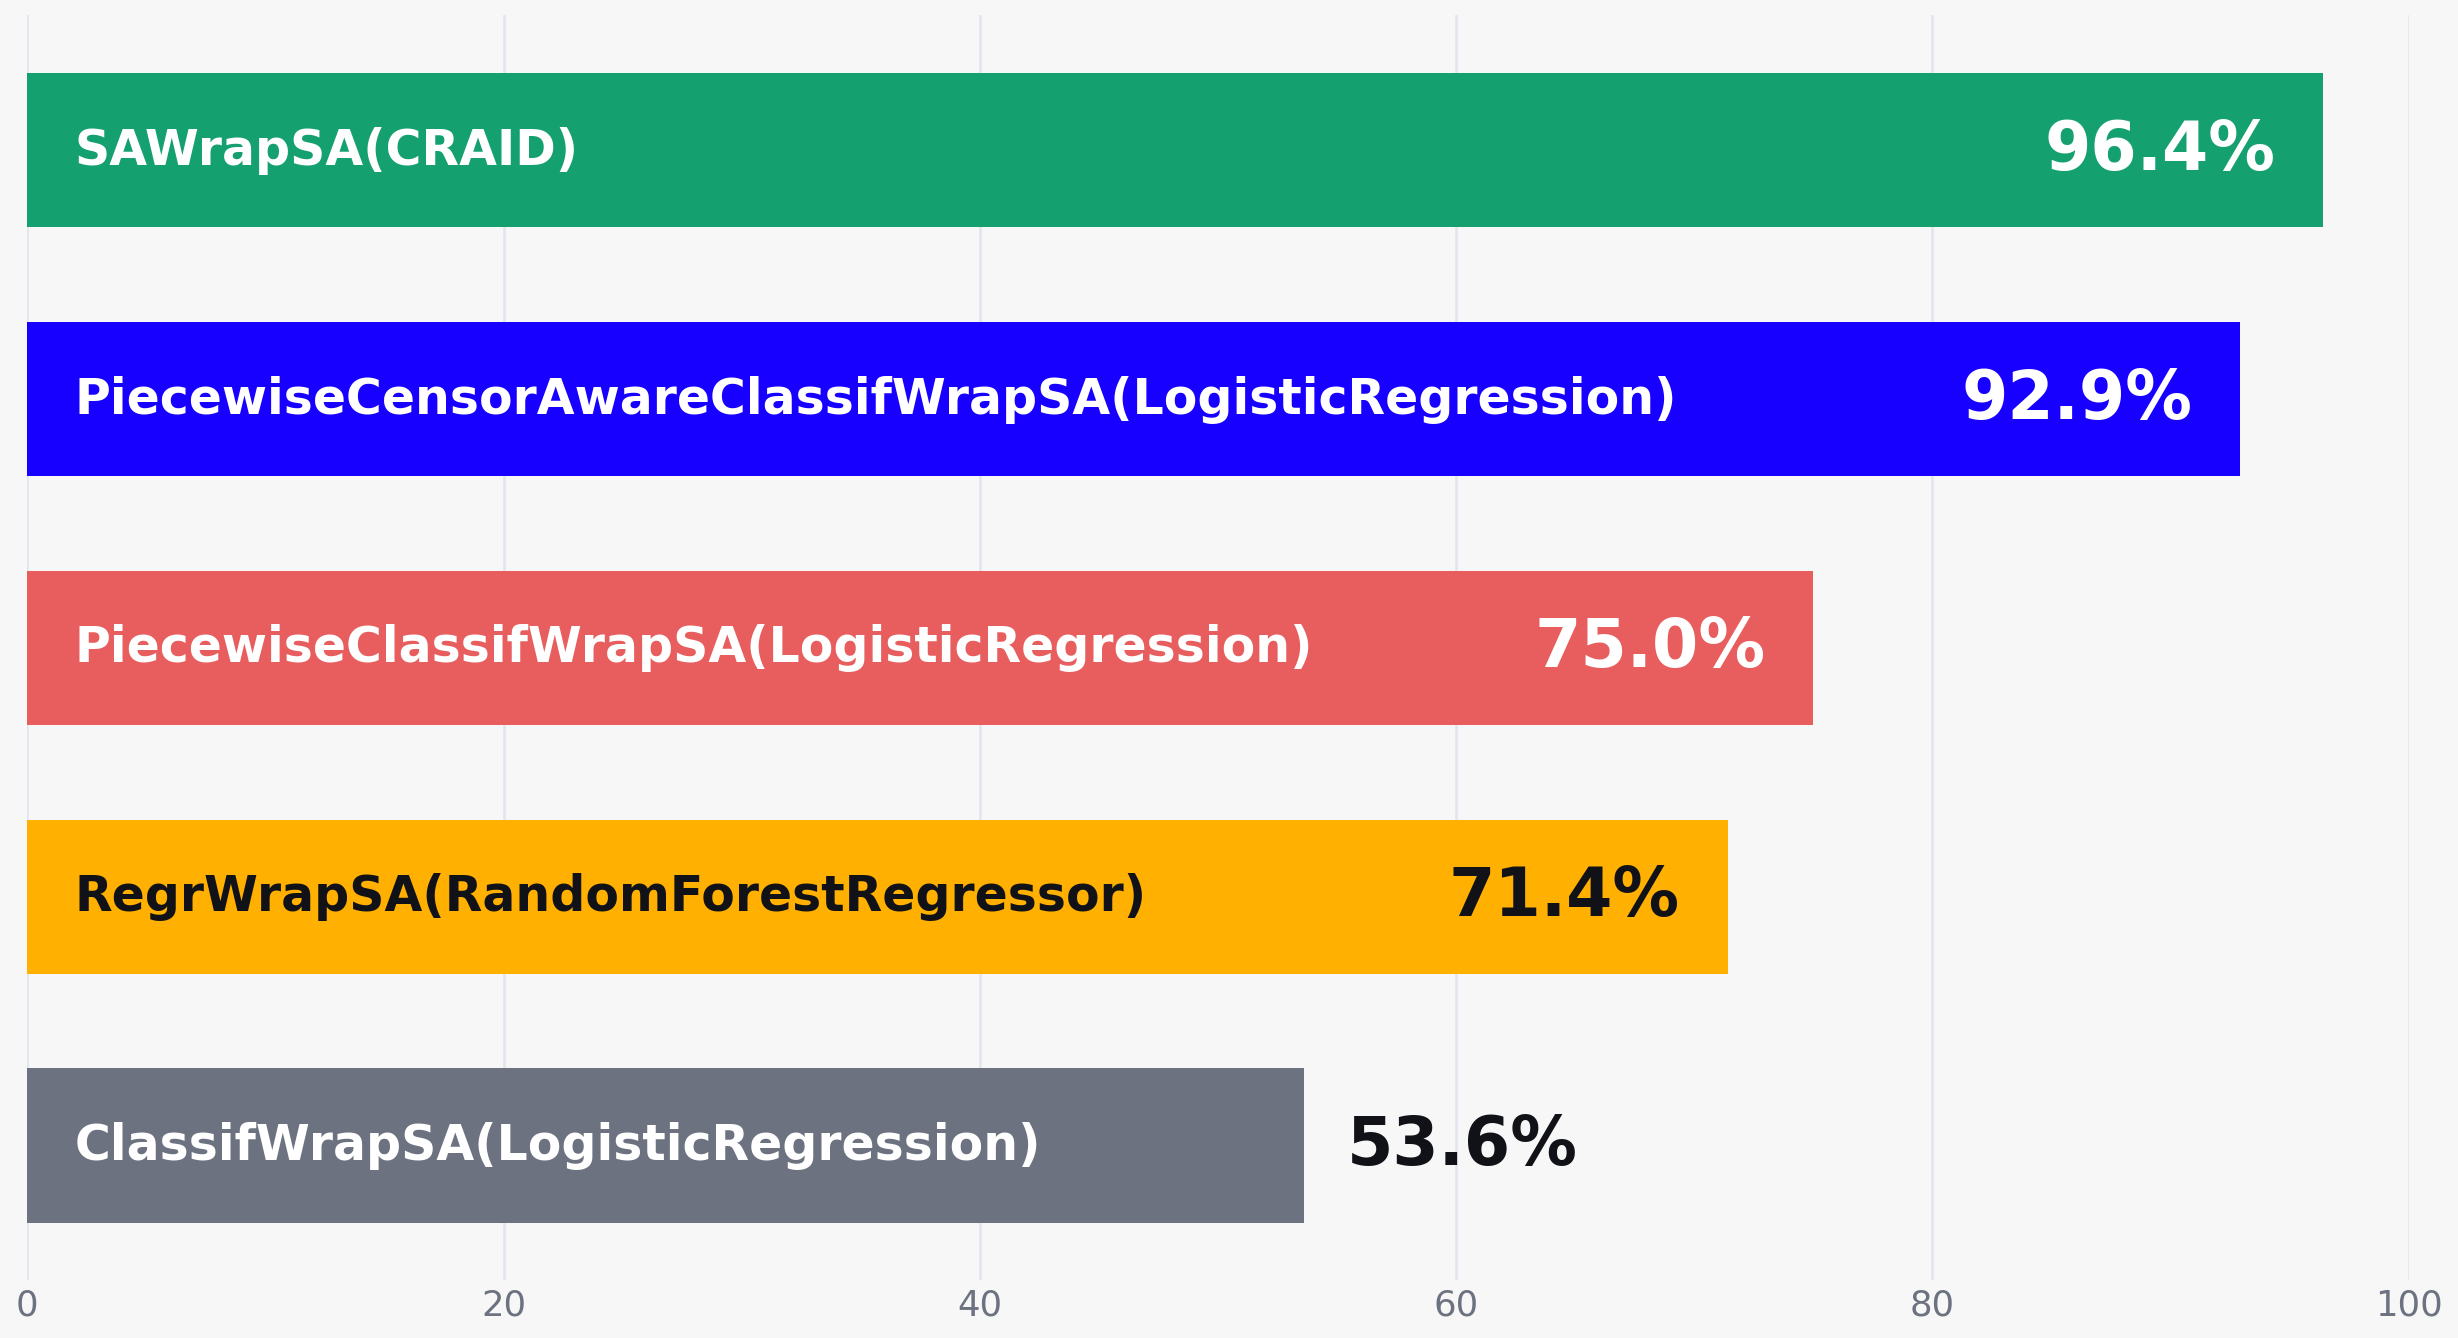

Saved PNG: outputs/manual-sawrap-product/presentations/group-results-chart/sawrap_selected_models_winrate.png
Saved SVG: outputs/manual-sawrap-product/presentations/group-results-chart/sawrap_selected_models_winrate.svg
Saved CSV: outputs/manual-sawrap-product/presentations/group-results-chart/sawrap_model_winrate.csv


In [ ]:
# Presentation chart: selected model winrate from 0 to 100.
# Winrate is calculated for every model as a pairwise rank winrate:
# percentage of models with a worse Avg_Position; equal ranks count as 0.5 win.

from pathlib import Path
import re

import pandas as pd
import matplotlib
if "get_ipython" not in globals():
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

RESULTS_CHART_DIR = Path("outputs/manual-sawrap-product/presentations/group-results-chart")
RESULTS_CHART_DIR.mkdir(parents=True, exist_ok=True)

LEADERBOARD_PATH = globals().get("LEADERBOARD_PATH", "UI/tables/leaderboards_by_task.xlsx")

leaderboard = pd.read_excel(LEADERBOARD_PATH, sheet_name="OVERALL_ALL").copy()
leaderboard["Avg_Position"] = pd.to_numeric(leaderboard["Avg_Position"], errors="coerce")
leaderboard = leaderboard.dropna(subset=["Avg_Position"]).reset_index(drop=True)

ranks = leaderboard["Avg_Position"]
n_models = len(leaderboard)


def rank_winrate(rank):
    wins = (ranks > rank).sum()
    ties = (ranks == rank).sum() - 1
    return 100 * (wins + 0.5 * ties) / (n_models - 1)


leaderboard["Winrate"] = leaderboard["Avg_Position"].map(rank_winrate).clip(0, 100).round(1)


CLASSIF_WRAPPED_MODELS = {
    "LogisticRegression",
    "KNeighborsClassifier",
    "DecisionTreeClassifier",
    "RandomForestClassifier",
    "GradientBoostingClassifier",
    "SVC",
}

REGR_WRAPPED_MODELS = {
    "ElasticNet",
    "DecisionTreeRegressor",
    "RandomForestRegressor",
    "GradientBoostingRegressor",
    "SVR",
    "KNeighborsRegressor",
}

SURV_WRAPPED_MODELS = {
    "KaplanMeierFitter",
    "CoxPHSurvivalAnalysis",
    "RandomSurvivalForest",
    "SurvivalTree",
    "GradientBoostingSurvivalAnalysis",
    "CRAID",
    "ParallelBootstrapCRAID",
}


def wrapper_plot_name(method):
    method = str(method)
    piecewise = re.match(r"^(Piecewise(?:CensorAware)?ClassifWrapSA)\(([^,]+),\s*times=(\d+)\)$", method)
    if piecewise:
        family, base_model, times = piecewise.groups()
        return f"{family}({base_model})"
    if method in CLASSIF_WRAPPED_MODELS:
        return f"ClassifWrapSA({method})"
    if method in REGR_WRAPPED_MODELS:
        return f"RegrWrapSA({method})"
    if method in SURV_WRAPPED_MODELS:
        return f"SAWrapSA({method})"
    return method


selected_methods = [
    "CRAID",
    "RandomForestRegressor",
    "LogisticRegression",
    "PiecewiseClassifWrapSA(LogisticRegression, times=8)",
    "PiecewiseCensorAwareClassifWrapSA(LogisticRegression, times=16)",
]

method_colors = {
    "CRAID": "#14A06F",
    "RandomForestRegressor": "#FFB000",
    "LogisticRegression": "#6C7280",
    "PiecewiseClassifWrapSA(LogisticRegression, times=8)": "#E85D5D",
    "PiecewiseCensorAwareClassifWrapSA(LogisticRegression, times=16)": "#1700FF",
}

leaderboard["Wrapper"] = leaderboard["Method"].map(wrapper_plot_name)

winrate_table = (
    leaderboard[["Method", "Wrapper", "Avg_Position", "Winrate"]]
    .sort_values(["Winrate", "Avg_Position", "Method"], ascending=[False, True, True])
    .reset_index(drop=True)
)
winrate_table.to_csv(RESULTS_CHART_DIR / "sawrap_model_winrate.csv", index=False)

selected_winrate = (
    leaderboard[leaderboard["Method"].isin(selected_methods)]
    .assign(plot_label=lambda df: df["Method"].map(wrapper_plot_name))
    .sort_values("Winrate", ascending=True)
    .reset_index(drop=True)
)

missing_methods = sorted(set(selected_methods) - set(selected_winrate["Method"]))
if missing_methods:
    raise ValueError(f"Missing selected methods in leaderboard: {missing_methods}")

fig, ax = plt.subplots(figsize=(16, 9), dpi=160, facecolor="#F7F7F8")
ax.set_facecolor("#F7F7F8")

bars = ax.barh(
    range(len(selected_winrate)),
    selected_winrate["Winrate"],
    color=selected_winrate["Method"].map(method_colors),
    height=0.62,
)

ax.set_xlim(0, 100)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_yticks([])
ax.tick_params(axis="y", length=0, labelleft=False)
ax.tick_params(axis="x", labelsize=16, colors="#6C7280", length=0)
ax.grid(axis="x", color="#E2E5EC", linewidth=1.2)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)

for bar, (_, row) in zip(bars, selected_winrate.iterrows()):
    value = float(row["Winrate"])
    y = bar.get_y() + bar.get_height() / 2
    text_color = "#111217" if row["Method"] == "RandomForestRegressor" else "#FFFFFF"
    ax.text(
        2.0,
        y,
        row["plot_label"],
        va="center",
        ha="left",
        fontsize=22,
        fontweight="bold",
        color=text_color,
    )
    percent_inside = value >= 62
    ax.text(
        value - 2.0 if percent_inside else value + 1.8,
        y,
        f"{value:.1f}%",
        va="center",
        ha="right" if percent_inside else "left",
        fontsize=30,
        fontweight="bold",
        color=text_color if percent_inside else "#111217",
    )

plt.tight_layout(pad=3)

png_path = RESULTS_CHART_DIR / "sawrap_selected_models_winrate.png"
svg_path = RESULTS_CHART_DIR / "sawrap_selected_models_winrate.svg"
fig.savefig(png_path, bbox_inches="tight", facecolor=fig.get_facecolor())
fig.savefig(svg_path, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

try:
    display(winrate_table)
except NameError:
    print(winrate_table.to_string(index=False))

print(f"Saved PNG: {png_path}")
print(f"Saved SVG: {svg_path}")
print(f"Saved CSV: {RESULTS_CHART_DIR / 'sawrap_model_winrate.csv'}")


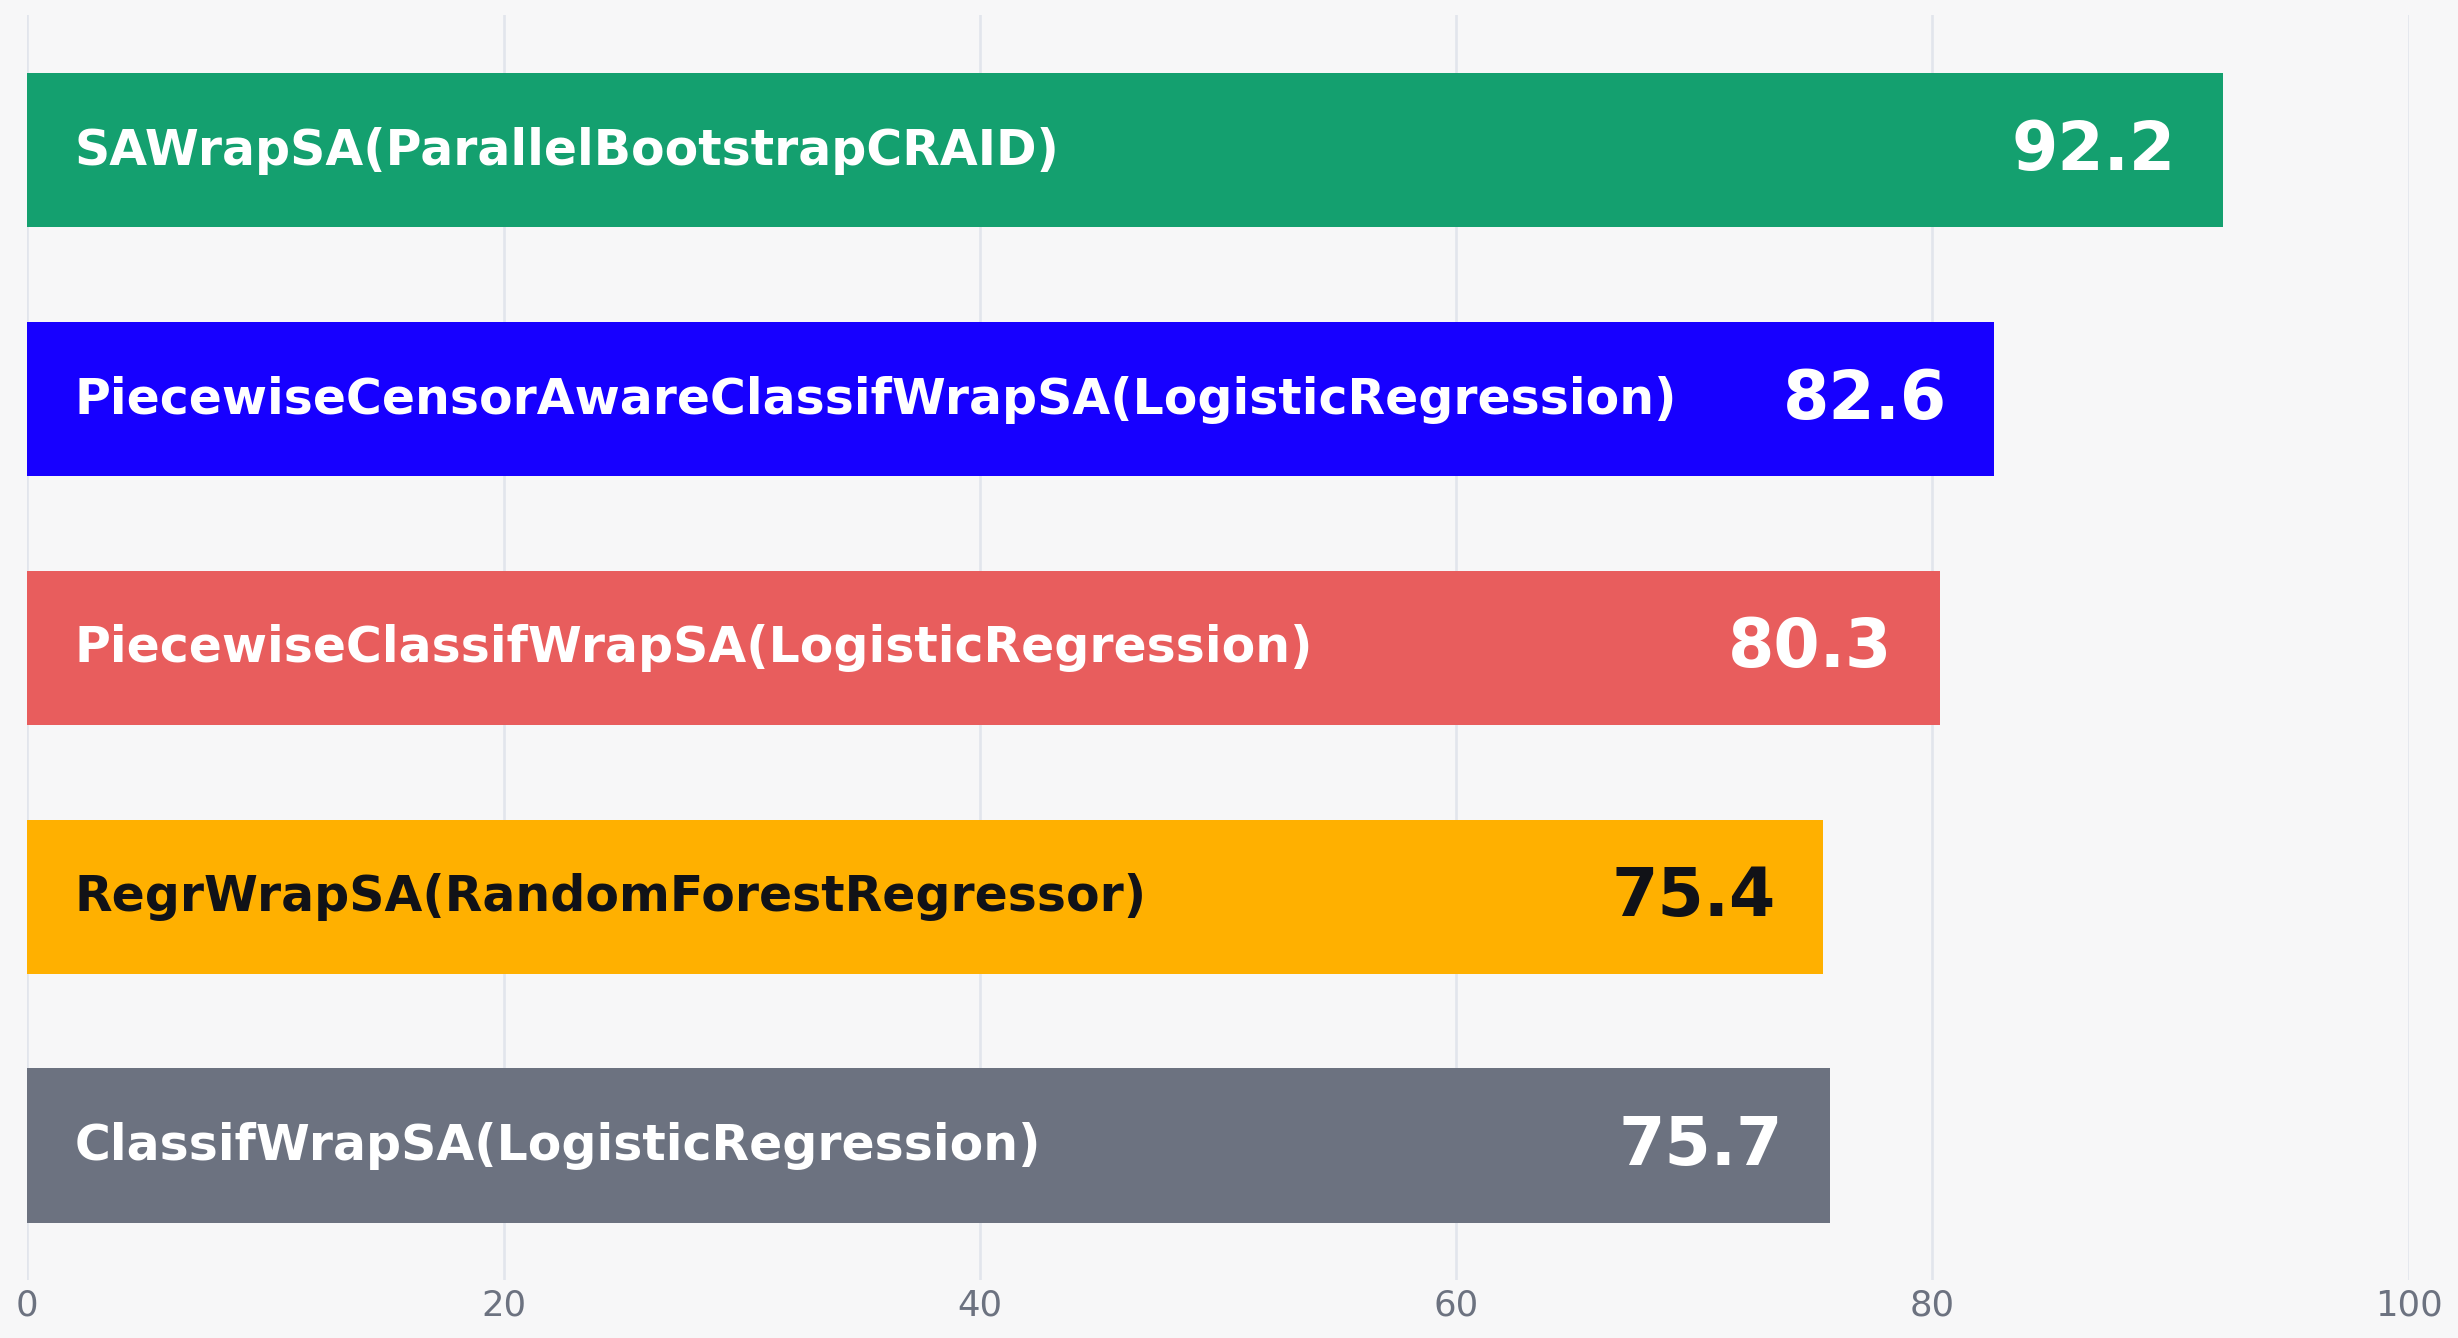

Method,Wrapper,group,Datasets,Weighted_Score,AUC_EVENT_Score,LOGLOSS_EVENT_Score,RMSE_EVENT_Score,RMSE_TIME_Score,R2_TIME_Score,MAPE_TIME_Score,MEDAPE_TIME_Score,SPEARMAN_TIME_Score,RMSLE_TIME_Score,CI_Score,IBS_Score,AUPRC_Score
ParallelBootstrapCRAID,SAWrapSA(ParallelBootstrapCRAID),survival,7,92.2,87.3,95.2,82.4,96.7,98.2,80.7,91.6,90.8,97.8,91.5,97.2,93.9
CRAID,SAWrapSA(CRAID),survival,7,85.7,78.3,93.4,73.1,94.8,97.0,81.5,92.4,65.1,98.9,73.2,90.7,98.8
"PiecewiseCensorAwareClassifWrapSA(RandomForestClassifier, times=16)",PiecewiseCensorAwareClassifWrapSA(RandomForestClassifier),censor_aware_piecewise,7,83.4,87.0,95.1,82.8,83.1,87.6,55.0,84.4,69.3,97.1,73.1,90.1,86.0
"PiecewiseCensorAwareClassifWrapSA(LogisticRegression, times=16)",PiecewiseCensorAwareClassifWrapSA(LogisticRegression),censor_aware_piecewise,7,82.6,88.8,96.3,82.9,82.0,86.6,54.8,84.4,64.0,97.1,68.1,88.9,87.5
"PiecewiseCensorAwareClassifWrapSA(GradientBoostingClassifier, times=16)",PiecewiseCensorAwareClassifWrapSA(GradientBoostingClassifier),censor_aware_piecewise,7,81.3,84.2,95.4,78.7,79.0,84.0,52.2,81.4,66.8,97.2,71.3,88.1,88.8
"PiecewiseClassifWrapSA(RandomForestClassifier, times=8)",PiecewiseClassifWrapSA(RandomForestClassifier),piecewise,7,81.1,92.4,97.1,85.5,73.2,79.1,41.8,72.1,65.3,95.3,69.5,97.8,75.9
"PiecewiseClassifWrapSA(LogisticRegression, times=8)",PiecewiseClassifWrapSA(LogisticRegression),piecewise,7,80.3,91.3,97.1,82.7,72.9,78.8,42.0,74.7,61.5,95.5,65.8,97.5,77.2
"PiecewiseClassifWrapSA(GradientBoostingClassifier, times=4)",PiecewiseClassifWrapSA(GradientBoostingClassifier),piecewise,7,76.7,95.4,96.1,76.3,67.1,73.9,29.9,65.1,54.5,94.2,60.7,92.5,78.2
RandomForestClassifier,ClassifWrapSA(RandomForestClassifier),classification,7,76.4,97.6,99.5,98.4,75.1,79.9,60.5,73.7,45.3,95.3,54.5,84.1,24.3
"PiecewiseCensorAwareClassifWrapSA(DecisionTreeClassifier, times=16)",PiecewiseCensorAwareClassifWrapSA(DecisionTreeClassifier),censor_aware_piecewise,7,76.4,77.2,84.6,73.9,78.8,84.4,54.5,82.3,52.0,97.1,62.2,83.3,87.7


Saved PNG: outputs/manual-sawrap-product/presentations/group-results-chart/sawrap_best_group_weighted_score.png
Saved SVG: outputs/manual-sawrap-product/presentations/group-results-chart/sawrap_best_group_weighted_score.svg
Saved CSV: outputs/manual-sawrap-product/presentations/group-results-chart/sawrap_weighted_metric_scores.csv
Saved XLSX: outputs/manual-sawrap-product/presentations/group-results-chart/sawrap_weighted_metric_scores.xlsx


In [ ]:
# Presentation table and chart: weighted metric score from 0 to 100.
# Each metric is normalized inside each dataset: best metric value = 100, worst = 0.
# Weighted_Score is the weighted average across all available project metrics.

from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib
if "get_ipython" not in globals():
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from rank import (
    BASE_FILES,
    PIECEWISE_FILES,
    BASE_MODELS,
    compute_global_piecewise_times,
    extract_piecewise_rows,
    _find_method_col,
    _prepare_method_frame,
)
from UI.helpers_ai_advice import TASK_CONFIGS

TABLES_DIR = Path("UI/tables")
RESULTS_CHART_DIR = Path("outputs/manual-sawrap-product/presentations/group-results-chart")
RESULTS_CHART_DIR.mkdir(parents=True, exist_ok=True)

METRIC_CONFIGS = []
for task_name in ["classification", "regression", "survival"]:
    for metric in TASK_CONFIGS[task_name]["metrics"]:
        METRIC_CONFIGS.append({**metric, "task": task_name, "column": f"{metric['key']}_mean"})

METRIC_SCORE_COLUMNS = [f"{metric['key']}_Score" for metric in METRIC_CONFIGS]

CLASSIF_WRAPPED_MODELS = {
    "LogisticRegression",
    "KNeighborsClassifier",
    "DecisionTreeClassifier",
    "RandomForestClassifier",
    "GradientBoostingClassifier",
    "SVC",
}

REGR_WRAPPED_MODELS = {
    "ElasticNet",
    "DecisionTreeRegressor",
    "RandomForestRegressor",
    "GradientBoostingRegressor",
    "SVR",
    "KNeighborsRegressor",
}

SURV_WRAPPED_MODELS = {
    "KaplanMeierFitter",
    "CoxPHSurvivalAnalysis",
    "RandomSurvivalForest",
    "SurvivalTree",
    "GradientBoostingSurvivalAnalysis",
    "CRAID",
    "ParallelBootstrapCRAID",
}

PIECEWISE_PATTERN = re.compile(
    r"^(Piecewise(?:CensorAware)?ClassifWrapSA)\(([^,]+),\s*times=(\d+)\)$"
)

GROUP_LABELS = {
    "survival": "Survival\nanalysis",
    "censor_aware_piecewise": "Censor-aware\npiecewise",
    "piecewise": "Piecewise",
    "regression": "Regression",
    "classification": "Classification",
}

GROUP_COLORS = {
    "survival": "#14A06F",
    "censor_aware_piecewise": "#1700FF",
    "piecewise": "#E85D5D",
    "regression": "#FFB000",
    "classification": "#6C7280",
}

GROUP_ORDER = [
    "survival",
    "censor_aware_piecewise",
    "piecewise",
    "regression",
    "classification",
]


def wrapper_plot_name(method):
    method = str(method)
    piecewise = PIECEWISE_PATTERN.match(method)
    if piecewise:
        family, base_model, times = piecewise.groups()
        return f"{family}({base_model})"
    if method in CLASSIF_WRAPPED_MODELS:
        return f"ClassifWrapSA({method})"
    if method in REGR_WRAPPED_MODELS:
        return f"RegrWrapSA({method})"
    if method in SURV_WRAPPED_MODELS:
        return f"SAWrapSA({method})"
    return method


def method_group(method):
    method = str(method)
    piecewise = PIECEWISE_PATTERN.match(method)
    if piecewise:
        family = piecewise.group(1)
        if family == "PiecewiseCensorAwareClassifWrapSA":
            return "censor_aware_piecewise"
        return "piecewise"
    if method in CLASSIF_WRAPPED_MODELS:
        return "classification"
    if method in REGR_WRAPPED_MODELS:
        return "regression"
    if method in SURV_WRAPPED_MODELS:
        return "survival"
    return "other"


def normalize_metric(values, direction):
    values = pd.to_numeric(values, errors="coerce")
    min_value = values.min(skipna=True)
    max_value = values.max(skipna=True)
    if pd.isna(min_value) or pd.isna(max_value):
        return pd.Series(np.nan, index=values.index)
    if np.isclose(max_value, min_value):
        return pd.Series(np.where(values.notna(), 100.0, np.nan), index=values.index)
    if direction == "higher":
        return 100 * (values - min_value) / (max_value - min_value)
    return 100 * (max_value - values) / (max_value - min_value)


def weighted_row_score(frame):
    weighted_sum = pd.Series(0.0, index=frame.index)
    weight_sum = pd.Series(0.0, index=frame.index)
    for metric in METRIC_CONFIGS:
        score_col = f"{metric['key']}_Score"
        if score_col not in frame.columns:
            continue
        values = pd.to_numeric(frame[score_col], errors="coerce")
        present = values.notna()
        weighted_sum = weighted_sum.add(values.fillna(0) * metric["weight"], fill_value=0)
        weight_sum = weight_sum.add(present.astype(float) * metric["weight"], fill_value=0)
    return weighted_sum.div(weight_sum.replace(0, np.nan))


selected_piecewise_times = compute_global_piecewise_times(TABLES_DIR)
per_dataset_scores = []

for base_filename in BASE_FILES:
    dataset_name = Path(base_filename).stem
    base_path = TABLES_DIR / base_filename
    if not base_path.exists():
        continue

    base_df = pd.read_excel(base_path)
    base_df, method_col = _prepare_method_frame(base_df, dataset_name, allowed_methods=BASE_MODELS)

    piecewise_rows = pd.DataFrame(columns=base_df.columns)
    piecewise_name = PIECEWISE_FILES.get(dataset_name)
    piecewise_path = TABLES_DIR / piecewise_name if piecewise_name else None
    if piecewise_path and piecewise_path.exists():
        piecewise_df = pd.read_excel(piecewise_path)
        piecewise_rows, _ = extract_piecewise_rows(
            piecewise_df,
            dataset_name,
            target_method_col=method_col,
            selected_times=selected_piecewise_times,
        )

    dataset_frame = (
        pd.concat([base_df, piecewise_rows], ignore_index=True, sort=False)
        if not piecewise_rows.empty
        else base_df.copy()
    )
    dataset_frame[method_col] = dataset_frame[method_col].astype(str).str.strip()

    score_frame = pd.DataFrame({
        "Dataset": dataset_name,
        "Method": dataset_frame[method_col],
    })
    score_frame["Wrapper"] = score_frame["Method"].map(wrapper_plot_name)
    score_frame["group"] = score_frame["Method"].map(method_group)

    for metric in METRIC_CONFIGS:
        raw_col = metric["column"]
        score_col = f"{metric['key']}_Score"
        if raw_col not in dataset_frame.columns:
            score_frame[score_col] = np.nan
            continue
        score_frame[score_col] = normalize_metric(dataset_frame[raw_col], metric["direction"])

    score_frame["Weighted_Score"] = weighted_row_score(score_frame)
    per_dataset_scores.append(score_frame)

metric_score_long = pd.concat(per_dataset_scores, ignore_index=True)

model_weighted_score_table = (
    metric_score_long
    .groupby(["Method", "Wrapper", "group"], as_index=False)
    .agg(
        Datasets=("Dataset", "nunique"),
        Weighted_Score=("Weighted_Score", "mean"),
        **{col: (col, "mean") for col in METRIC_SCORE_COLUMNS if col in metric_score_long.columns},
    )
    .sort_values(["Weighted_Score", "Method"], ascending=[False, True])
    .reset_index(drop=True)
)
model_weighted_score_table["Weighted_Score"] = model_weighted_score_table["Weighted_Score"].round(1)
for col in METRIC_SCORE_COLUMNS:
    if col in model_weighted_score_table.columns:
        model_weighted_score_table[col] = model_weighted_score_table[col].round(1)

score_csv_path = RESULTS_CHART_DIR / "sawrap_weighted_metric_scores.csv"
score_xlsx_path = RESULTS_CHART_DIR / "sawrap_weighted_metric_scores.xlsx"
model_weighted_score_table.to_csv(score_csv_path, index=False)
model_weighted_score_table.to_excel(score_xlsx_path, index=False)

FIXED_GROUP_METHODS = {
    "censor_aware_piecewise": "PiecewiseCensorAwareClassifWrapSA(LogisticRegression, times=16)",
    "piecewise": "PiecewiseClassifWrapSA(LogisticRegression, times=8)",
    "classification": "LogisticRegression",
}

selected_group_rows = []
for group in GROUP_ORDER:
    group_rows = model_weighted_score_table[model_weighted_score_table["group"] == group].copy()
    fixed_method = FIXED_GROUP_METHODS.get(group)
    if fixed_method is not None:
        group_rows = group_rows[group_rows["Method"] == fixed_method].copy()
        if group_rows.empty:
            raise ValueError(f"Missing fixed method for {group}: {fixed_method}")
    else:
        group_rows = group_rows.sort_values(["Weighted_Score", "Method"], ascending=[False, True]).head(1)
    selected_group_rows.append(group_rows.head(1))

best_by_group_weighted_score = pd.concat(selected_group_rows, ignore_index=True)
best_by_group_weighted_score["order"] = best_by_group_weighted_score["group"].map({group: i for i, group in enumerate(GROUP_ORDER)})
best_by_group_weighted_score = best_by_group_weighted_score.sort_values("order").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 9), dpi=160, facecolor="#F7F7F8")
ax.set_facecolor("#F7F7F8")

bars = ax.barh(
    range(len(best_by_group_weighted_score)),
    best_by_group_weighted_score["Weighted_Score"],
    color=best_by_group_weighted_score["group"].map(GROUP_COLORS),
    height=0.62,
)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_yticks([])
ax.tick_params(axis="y", length=0, labelleft=False)
ax.tick_params(axis="x", labelsize=16, colors="#6C7280", length=0)
ax.grid(axis="x", color="#E2E5EC", linewidth=1.2)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)

for bar, (_, row) in zip(bars, best_by_group_weighted_score.iterrows()):
    value = float(row["Weighted_Score"])
    y = bar.get_y() + bar.get_height() / 2
    text_color = "#111217" if row["group"] == "regression" else "#FFFFFF"
    label_fontsize = 18 if len(row["Wrapper"]) > 55 else 22
    ax.text(
        2.0,
        y,
        row["Wrapper"],
        va="center",
        ha="left",
        fontsize=label_fontsize,
        fontweight="bold",
        color=text_color,
    )
    score_inside = value >= 62
    ax.text(
        value - 2.0 if score_inside else value + 1.8,
        y,
        f"{value:.1f}",
        va="center",
        ha="right" if score_inside else "left",
        fontsize=30,
        fontweight="bold",
        color=text_color if score_inside else "#111217",
    )

plt.tight_layout(pad=3)

weighted_png_path = RESULTS_CHART_DIR / "sawrap_best_group_weighted_score.png"
weighted_svg_path = RESULTS_CHART_DIR / "sawrap_best_group_weighted_score.svg"
fig.savefig(weighted_png_path, bbox_inches="tight", facecolor=fig.get_facecolor())
fig.savefig(weighted_svg_path, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

try:
    display(model_weighted_score_table)
except NameError:
    print(model_weighted_score_table.to_string(index=False))

print(f"Saved PNG: {weighted_png_path}")
print(f"Saved SVG: {weighted_svg_path}")
print(f"Saved CSV: {score_csv_path}")
print(f"Saved XLSX: {score_xlsx_path}")


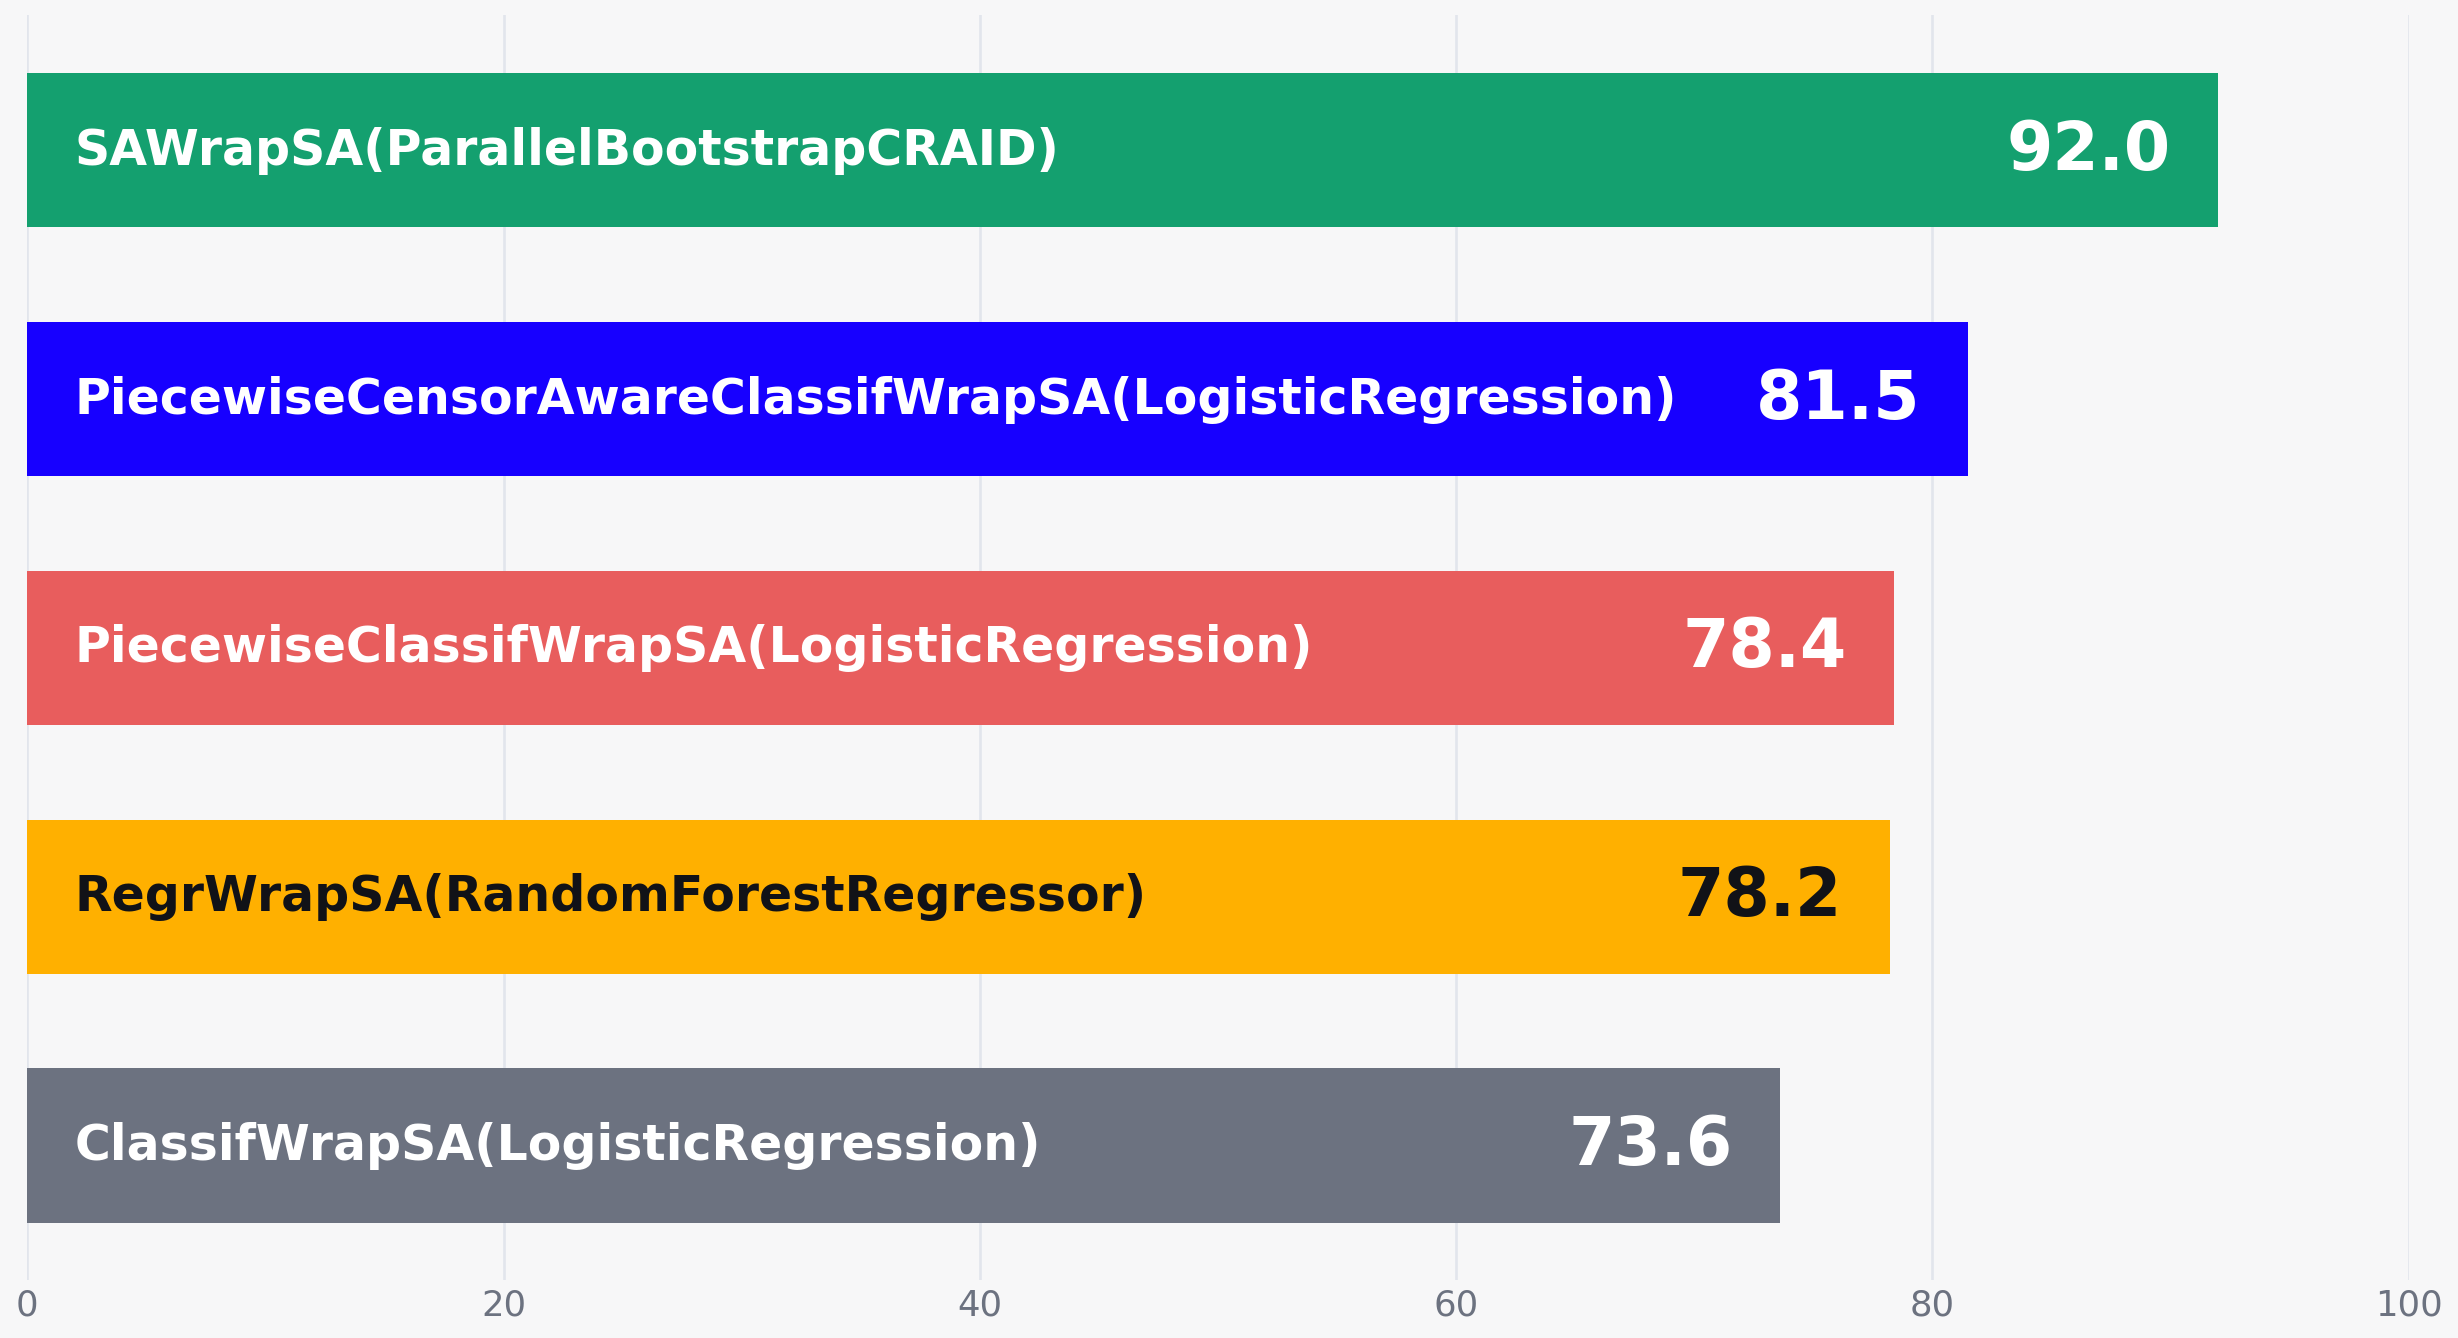

Method,Wrapper,group,Datasets,Equal_Metric_Score,AUC_EVENT_Score,LOGLOSS_EVENT_Score,RMSE_EVENT_Score,RMSE_TIME_Score,R2_TIME_Score,MAPE_TIME_Score,SPEARMAN_TIME_Score,RMSLE_TIME_Score,CI_Score,IBS_Score,AUPRC_Score
ParallelBootstrapCRAID,SAWrapSA(ParallelBootstrapCRAID),survival,7,92.0,87.3,95.2,82.4,96.7,98.2,80.7,90.8,97.8,91.5,97.2,93.9
CRAID,SAWrapSA(CRAID),survival,7,85.9,78.3,93.4,73.1,94.8,97.0,81.5,65.1,98.9,73.2,90.7,98.8
"PiecewiseCensorAwareClassifWrapSA(RandomForestClassifier, times=16)",PiecewiseCensorAwareClassifWrapSA(RandomForestClassifier),censor_aware_piecewise,7,82.4,87.0,95.1,82.8,83.1,87.6,55.0,69.3,97.1,73.1,90.1,86.0
"PiecewiseCensorAwareClassifWrapSA(LogisticRegression, times=16)",PiecewiseCensorAwareClassifWrapSA(LogisticRegression),censor_aware_piecewise,7,81.5,88.8,96.3,82.9,82.0,86.6,54.8,64.0,97.1,68.1,88.9,87.5
"PiecewiseCensorAwareClassifWrapSA(GradientBoostingClassifier, times=16)",PiecewiseCensorAwareClassifWrapSA(GradientBoostingClassifier),censor_aware_piecewise,7,80.5,84.2,95.4,78.7,79.0,84.0,52.2,66.8,97.2,71.3,88.1,88.8
"PiecewiseClassifWrapSA(RandomForestClassifier, times=8)",PiecewiseClassifWrapSA(RandomForestClassifier),piecewise,7,79.3,92.4,97.1,85.5,73.2,79.1,41.8,65.3,95.3,69.5,97.8,75.9
"PiecewiseClassifWrapSA(LogisticRegression, times=8)",PiecewiseClassifWrapSA(LogisticRegression),piecewise,7,78.4,91.3,97.1,82.7,72.9,78.8,42.0,61.5,95.5,65.8,97.5,77.2
RandomForestRegressor,RegrWrapSA(RandomForestRegressor),regression,7,78.2,51.6,84.0,42.7,99.4,99.6,87.9,87.0,100.0,92.6,28.3,87.3
GradientBoostingRegressor,RegrWrapSA(GradientBoostingRegressor),regression,7,77.1,52.4,80.2,40.1,98.6,99.2,88.9,89.8,97.3,92.2,28.8,81.1
ElasticNet,RegrWrapSA(ElasticNet),regression,7,77.0,56.6,84.5,48.9,96.8,98.2,84.9,90.2,95.9,91.2,21.1,78.8


Saved PNG: outputs/manual-sawrap-product/presentations/group-results-chart/sawrap_best_group_equal_metric_score.png
Saved SVG: outputs/manual-sawrap-product/presentations/group-results-chart/sawrap_best_group_equal_metric_score.svg
Saved CSV: outputs/manual-sawrap-product/presentations/group-results-chart/sawrap_equal_metric_scores.csv
Saved XLSX: outputs/manual-sawrap-product/presentations/group-results-chart/sawrap_equal_metric_scores.xlsx


In [1]:
# Presentation table and chart: equal-weight metric score from 0 to 100.
# Each metric is normalized inside each dataset: best metric value = 100, worst = 0.
# Equal_Metric_Score is the simple average across project metrics, excluding MEDAPE_TIME.

from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib
if "get_ipython" not in globals():
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from rank import (
    BASE_FILES,
    PIECEWISE_FILES,
    BASE_MODELS,
    compute_global_piecewise_times,
    extract_piecewise_rows,
    _prepare_method_frame,
)
from UI.helpers_ai_advice import TASK_CONFIGS

TABLES_DIR = Path("UI/tables")
RESULTS_CHART_DIR = Path("outputs/manual-sawrap-product/presentations/group-results-chart")
RESULTS_CHART_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDED_METRICS = {"MEDAPE_TIME"}

METRIC_CONFIGS = []
for task_name in ["classification", "regression", "survival"]:
    for metric in TASK_CONFIGS[task_name]["metrics"]:
        if metric["key"] in EXCLUDED_METRICS:
            continue
        METRIC_CONFIGS.append({**metric, "task": task_name, "column": f"{metric['key']}_mean"})

METRIC_SCORE_COLUMNS = [f"{metric['key']}_Score" for metric in METRIC_CONFIGS]

CLASSIF_WRAPPED_MODELS = {
    "LogisticRegression",
    "KNeighborsClassifier",
    "DecisionTreeClassifier",
    "RandomForestClassifier",
    "GradientBoostingClassifier",
    "SVC",
}

REGR_WRAPPED_MODELS = {
    "ElasticNet",
    "DecisionTreeRegressor",
    "RandomForestRegressor",
    "GradientBoostingRegressor",
    "SVR",
    "KNeighborsRegressor",
}

SURV_WRAPPED_MODELS = {
    "KaplanMeierFitter",
    "CoxPHSurvivalAnalysis",
    "RandomSurvivalForest",
    "SurvivalTree",
    "GradientBoostingSurvivalAnalysis",
    "CRAID",
    "ParallelBootstrapCRAID",
}

PIECEWISE_PATTERN = re.compile(
    r"^(Piecewise(?:CensorAware)?ClassifWrapSA)\(([^,]+),\s*times=(\d+)\)$"
)

GROUP_LABELS = {
    "survival": "Survival\nanalysis",
    "censor_aware_piecewise": "Censor-aware\npiecewise",
    "piecewise": "Piecewise",
    "regression": "Regression",
    "classification": "Classification",
}

GROUP_COLORS = {
    "survival": "#14A06F",
    "censor_aware_piecewise": "#1700FF",
    "piecewise": "#E85D5D",
    "regression": "#FFB000",
    "classification": "#6C7280",
}

GROUP_ORDER = [
    "survival",
    "censor_aware_piecewise",
    "piecewise",
    "regression",
    "classification",
]

FIXED_GROUP_METHODS = {
    "censor_aware_piecewise": "PiecewiseCensorAwareClassifWrapSA(LogisticRegression, times=16)",
    "piecewise": "PiecewiseClassifWrapSA(LogisticRegression, times=8)",
    "classification": "LogisticRegression",
}


def wrapper_plot_name(method):
    method = str(method)
    piecewise = PIECEWISE_PATTERN.match(method)
    if piecewise:
        family, base_model, times = piecewise.groups()
        return f"{family}({base_model})"
    if method in CLASSIF_WRAPPED_MODELS:
        return f"ClassifWrapSA({method})"
    if method in REGR_WRAPPED_MODELS:
        return f"RegrWrapSA({method})"
    if method in SURV_WRAPPED_MODELS:
        return f"SAWrapSA({method})"
    return method


def method_group(method):
    method = str(method)
    piecewise = PIECEWISE_PATTERN.match(method)
    if piecewise:
        family = piecewise.group(1)
        if family == "PiecewiseCensorAwareClassifWrapSA":
            return "censor_aware_piecewise"
        return "piecewise"
    if method in CLASSIF_WRAPPED_MODELS:
        return "classification"
    if method in REGR_WRAPPED_MODELS:
        return "regression"
    if method in SURV_WRAPPED_MODELS:
        return "survival"
    return "other"


def normalize_metric(values, direction):
    values = pd.to_numeric(values, errors="coerce")
    min_value = values.min(skipna=True)
    max_value = values.max(skipna=True)
    if pd.isna(min_value) or pd.isna(max_value):
        return pd.Series(np.nan, index=values.index)
    if np.isclose(max_value, min_value):
        return pd.Series(np.where(values.notna(), 100.0, np.nan), index=values.index)
    if direction == "higher":
        return 100 * (values - min_value) / (max_value - min_value)
    return 100 * (max_value - values) / (max_value - min_value)


def equal_metric_row_score(frame):
    present_cols = [col for col in METRIC_SCORE_COLUMNS if col in frame.columns]
    if not present_cols:
        return pd.Series(np.nan, index=frame.index)
    return frame[present_cols].mean(axis=1, skipna=True)


selected_piecewise_times = compute_global_piecewise_times(TABLES_DIR)
per_dataset_scores = []

for base_filename in BASE_FILES:
    dataset_name = Path(base_filename).stem
    base_path = TABLES_DIR / base_filename
    if not base_path.exists():
        continue

    base_df = pd.read_excel(base_path)
    base_df, method_col = _prepare_method_frame(base_df, dataset_name, allowed_methods=BASE_MODELS)

    piecewise_rows = pd.DataFrame(columns=base_df.columns)
    piecewise_name = PIECEWISE_FILES.get(dataset_name)
    piecewise_path = TABLES_DIR / piecewise_name if piecewise_name else None
    if piecewise_path and piecewise_path.exists():
        piecewise_df = pd.read_excel(piecewise_path)
        piecewise_rows, _ = extract_piecewise_rows(
            piecewise_df,
            dataset_name,
            target_method_col=method_col,
            selected_times=selected_piecewise_times,
        )

    dataset_frame = (
        pd.concat([base_df, piecewise_rows], ignore_index=True, sort=False)
        if not piecewise_rows.empty
        else base_df.copy()
    )
    dataset_frame[method_col] = dataset_frame[method_col].astype(str).str.strip()

    score_frame = pd.DataFrame({
        "Dataset": dataset_name,
        "Method": dataset_frame[method_col],
    })
    score_frame["Wrapper"] = score_frame["Method"].map(wrapper_plot_name)
    score_frame["group"] = score_frame["Method"].map(method_group)

    for metric in METRIC_CONFIGS:
        raw_col = metric["column"]
        score_col = f"{metric['key']}_Score"
        if raw_col not in dataset_frame.columns:
            score_frame[score_col] = np.nan
            continue
        score_frame[score_col] = normalize_metric(dataset_frame[raw_col], metric["direction"])

    score_frame["Equal_Metric_Score"] = equal_metric_row_score(score_frame)
    per_dataset_scores.append(score_frame)

metric_score_long_equal = pd.concat(per_dataset_scores, ignore_index=True)

equal_metric_score_table = (
    metric_score_long_equal
    .groupby(["Method", "Wrapper", "group"], as_index=False)
    .agg(
        Datasets=("Dataset", "nunique"),
        Equal_Metric_Score=("Equal_Metric_Score", "mean"),
        **{col: (col, "mean") for col in METRIC_SCORE_COLUMNS if col in metric_score_long_equal.columns},
    )
    .sort_values(["Equal_Metric_Score", "Method"], ascending=[False, True])
    .reset_index(drop=True)
)
equal_metric_score_table["Equal_Metric_Score"] = equal_metric_score_table["Equal_Metric_Score"].round(1)
for col in METRIC_SCORE_COLUMNS:
    if col in equal_metric_score_table.columns:
        equal_metric_score_table[col] = equal_metric_score_table[col].round(1)

equal_csv_path = RESULTS_CHART_DIR / "sawrap_equal_metric_scores.csv"
equal_xlsx_path = RESULTS_CHART_DIR / "sawrap_equal_metric_scores.xlsx"
equal_metric_score_table.to_csv(equal_csv_path, index=False)
equal_metric_score_table.to_excel(equal_xlsx_path, index=False)

selected_group_rows = []
for group in GROUP_ORDER:
    group_rows = equal_metric_score_table[equal_metric_score_table["group"] == group].copy()
    fixed_method = FIXED_GROUP_METHODS.get(group)
    if fixed_method is not None:
        group_rows = group_rows[group_rows["Method"] == fixed_method].copy()
        if group_rows.empty:
            raise ValueError(f"Missing fixed method for {group}: {fixed_method}")
    else:
        group_rows = group_rows.sort_values(["Equal_Metric_Score", "Method"], ascending=[False, True]).head(1)
    selected_group_rows.append(group_rows.head(1))

best_by_group_equal_metric_score = pd.concat(selected_group_rows, ignore_index=True)
best_by_group_equal_metric_score["order"] = best_by_group_equal_metric_score["group"].map({group: i for i, group in enumerate(GROUP_ORDER)})
best_by_group_equal_metric_score = best_by_group_equal_metric_score.sort_values("order").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 9), dpi=160, facecolor="#F7F7F8")
ax.set_facecolor("#F7F7F8")

bars = ax.barh(
    range(len(best_by_group_equal_metric_score)),
    best_by_group_equal_metric_score["Equal_Metric_Score"],
    color=best_by_group_equal_metric_score["group"].map(GROUP_COLORS),
    height=0.62,
)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_yticks([])
ax.tick_params(axis="y", length=0, labelleft=False)
ax.tick_params(axis="x", labelsize=16, colors="#6C7280", length=0)
ax.grid(axis="x", color="#E2E5EC", linewidth=1.2)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)

for bar, (_, row) in zip(bars, best_by_group_equal_metric_score.iterrows()):
    value = float(row["Equal_Metric_Score"])
    y = bar.get_y() + bar.get_height() / 2
    text_color = "#111217" if row["group"] == "regression" else "#FFFFFF"
    label_fontsize = 18 if len(row["Wrapper"]) > 55 else 22
    ax.text(
        2.0,
        y,
        row["Wrapper"],
        va="center",
        ha="left",
        fontsize=label_fontsize,
        fontweight="bold",
        color=text_color,
    )
    score_inside = value >= 62
    ax.text(
        value - 2.0 if score_inside else value + 1.8,
        y,
        f"{value:.1f}",
        va="center",
        ha="right" if score_inside else "left",
        fontsize=30,
        fontweight="bold",
        color=text_color if score_inside else "#111217",
    )

plt.tight_layout(pad=3)

equal_png_path = RESULTS_CHART_DIR / "sawrap_best_group_equal_metric_score.png"
equal_svg_path = RESULTS_CHART_DIR / "sawrap_best_group_equal_metric_score.svg"
fig.savefig(equal_png_path, bbox_inches="tight", facecolor=fig.get_facecolor())
fig.savefig(equal_svg_path, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

try:
    display(equal_metric_score_table)
except NameError:
    print(equal_metric_score_table.to_string(index=False))

print(f"Saved PNG: {equal_png_path}")
print(f"Saved SVG: {equal_svg_path}")
print(f"Saved CSV: {equal_csv_path}")
print(f"Saved XLSX: {equal_xlsx_path}")
